## Assignment: Diagnostic Analysis using Python

You’ll be working with real-world data to address a problem faced by the National Health Service (NHS). The analysis will require you to utilise Python to explore the available data, create visualisations to identify trends, and extract meaningful insights to inform decision-making. 

In [224]:
# preamble, define all dataframes and import libraries here

# Import the necessary libraries.
import pandas as pd
import numpy as np

from pandas.api.types import is_period_dtype

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import re
import time

from matplotlib.ticker import StrMethodFormatter

import requests
from bs4 import BeautifulSoup
import pandas as pd
parser = "lxml"
headers = {"User-Agent": "Mozilla/5.0"}

from datetime import date, datetime
import io
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

ad = pd.read_csv("actual_duration.csv")

ar = pd.read_csv("appointments_regional.csv")

nc = pd.read_excel("national_categories.xlsx")

tweets = pd.read_csv('tweets.csv')


# Assignment activity 1

### Plan your approach

#### Service utilisation

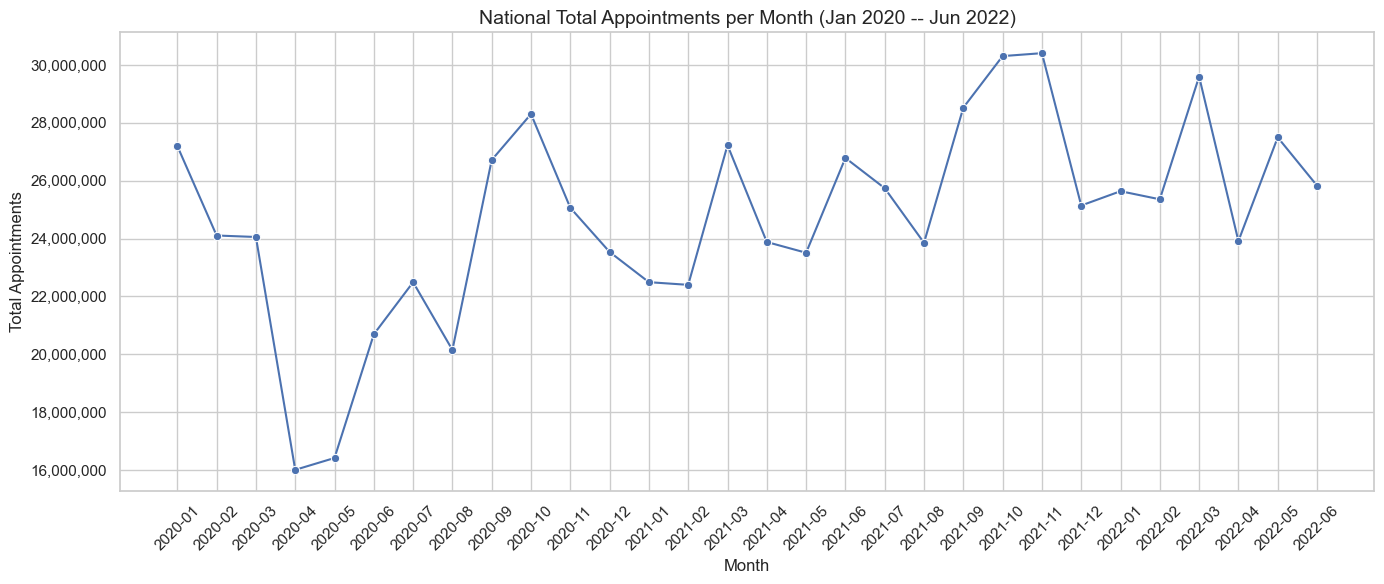

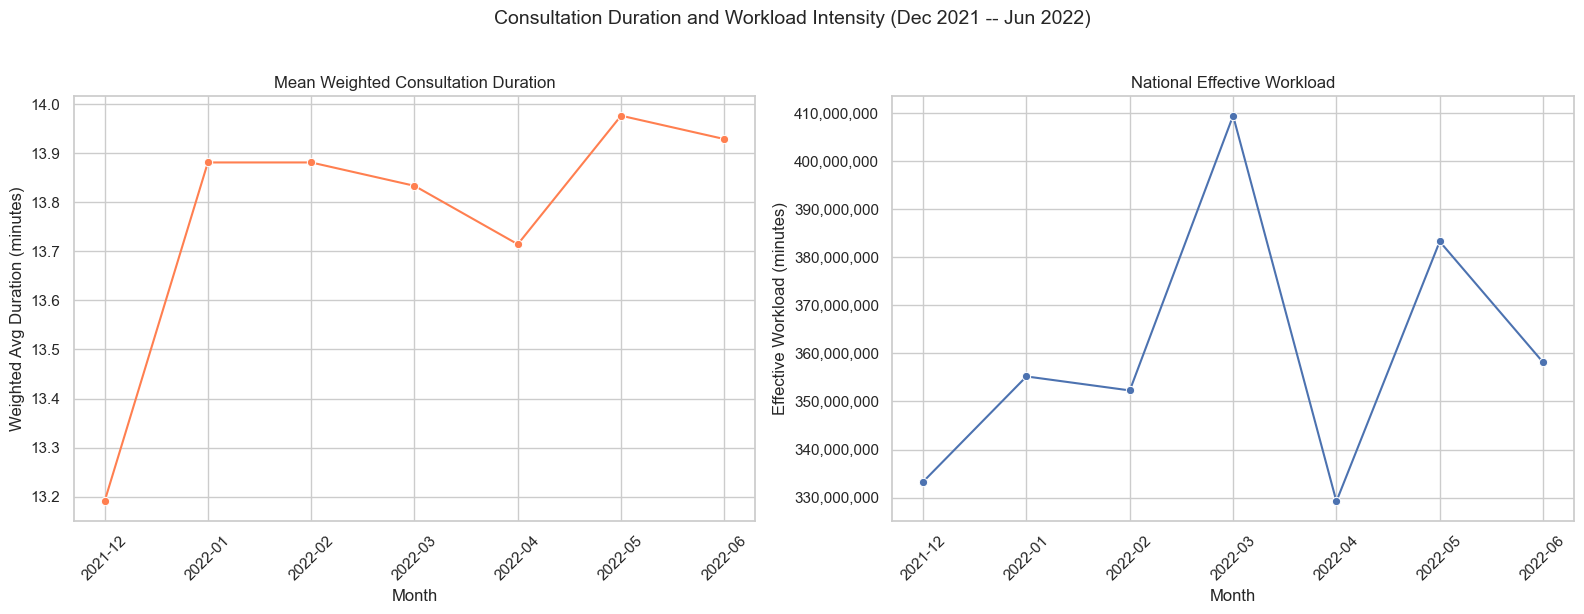

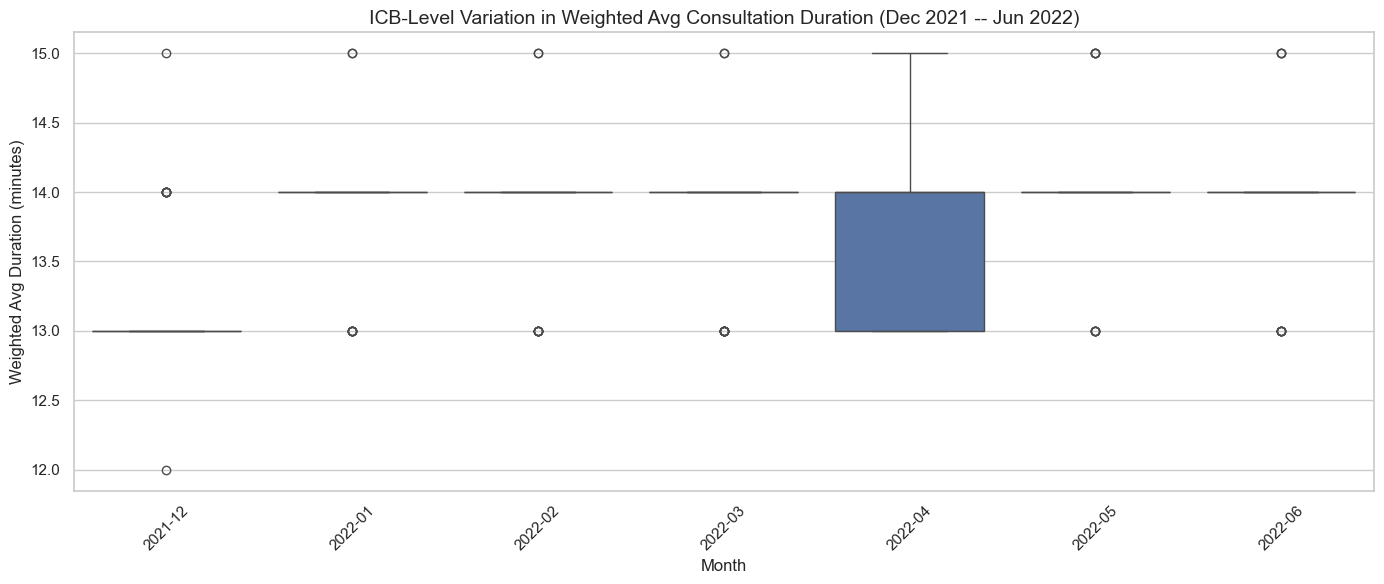

--- National Demand Summary (Full Period) ---
First month total: 27,199,296
Last month total:  25,828,078
Change over period: -5.0%

--- Duration Window Summary (Dec 2021 -- Jun 2022) ---
Mean consultation duration range: 13.2 -- 14.0 minutes
Total effective workload range: 329,217,527 -- 409,418,484 minutes


In [215]:
# Does current utilisation justify expanding capacity
# or can demand be met through better use of existing resources

# Data required
# appointments_regional.csv
# actual_duration.csv
# Fields used
# sub_icb_location_code
# appointment_month
# count_of_appointments
# appointment_status
# actual_duration
# service_setting
# appointment_mode

# Approach
# Aggregate monthly appointment volumes by Sub ICB location
# Compute growth rates over the reporting period
# Where available compute mean and median consultation duration
# Compare regions with sustained growth in volume and duration
# against regions with stable or declining duration

# Interpretation
# Rising volume and rising duration indicates capacity pressure
# Rising volume with stable or falling duration suggests efficiency gains

# ---------------------------------------------------------------------------

# Step 1, what do we mean by current utilisation and how can we measure this using available data:

  # defining current utilisation
# how many appointment slots are being filled vs how many appointments could be delivered 
# a first limitation of the available data is, no information regarding clinic room capacity, or GP working hours
# therefore we must approximate utilisation using proxies
# using proxies such as total monthly appointments, DNA rates, staff mix
# this can be summarised as:
  # how much demand is being processed by the system, and is that demand increasing?

# ---------------------------------------------------------------------------
   
# Step 2, defining 'expanding capacity'

# hiring more GPs, increasing clinic hours, opening more NHS buildings, increasing appointment slots
# but this cannot be directly observed, instead, we ask
  # is demand outpacing the system's ability to deliver?
# for example, if demand is rising sharply, DNA rates are low, then capacity expansion is justified
  # if demand is flat, DNA rates are high, remote appointments growing, 
  # then the system is reallocating internally and expansion may not be needed

# ---------------------------------------------------------------------------

# Step 3: merge appointments_regional with actual_duration at a comparable grain (ICB, month).
# Aggregate both datasets to monthly totals, then left join on ar to preserve all scheduled demand.
# This attaches duration coverage where available (ad starts later), enabling utilisation proxies.

# Reload from disk (safe reset)
ad = pd.read_csv("actual_duration.csv")
ar = pd.read_csv("appointments_regional.csv")

# ad: date string -> datetime -> period month
ad["appointment_date"] = pd.to_datetime(ad["appointment_date"], format="%d-%b-%y", errors="coerce")
ad["appointment_month"] = ad["appointment_date"].dt.to_period("M")

# ar: "YYYY-MM" string -> datetime -> period month
ar["appointment_month"] = pd.to_datetime(ar["appointment_month"], format="%Y-%m", errors="coerce").dt.to_period("M")

ar_month = (
    ar.groupby(["icb_ons_code", "appointment_month"], as_index=False)["count_of_appointments"]
      .sum()
      .rename(columns={"count_of_appointments": "appointments_total"})
)

ad_month = (
    ad.groupby(["icb_ons_code", "appointment_month"], as_index=False)["count_of_appointments"]
      .sum()
      .rename(columns={"count_of_appointments": "appointments_with_duration"})
)

ar_ad_merge = ar_month.merge(ad_month, how="left", on=["icb_ons_code", "appointment_month"])

ar_ad_merge.head()

# ar_ad_merge: Monthly ICB-level utilisation proxy dataset
# Structure:
# One row per (icb_ons_code, appointment_month)
# Columns:
  # appointments_total: Total scheduled appointments (demand processed)
  # appointments_with_duration: Appointments with recorded duration (where available)
# Purpose:
# This table aligns scheduled demand (appointments_regional) with 
# duration-recorded activity (actual_duration) at the same monthly grain.
# It enables:
  # Trend analysis of total demand over time
  # Assessment of duration coverage from Dec 2021 onward
  # Construction of utilisation proxies (e.g. duration intensity ratios)
# Missing values in appointments_with_duration reflect unavailable duration data, not zero activity.

# ---------------------------------------------------------------------------

# Step 4, now that we have the comparison of scheduled appointments with appointments that have a 
# measured duration, calculate an intensity proxy by estimating the consultation duration 
# per ICB, month, using weighted duration bands, 
# this allows us to move beyond simple appointment counts and approximate effective workload, 
# define effective workload as the product of total scheduled appointments and average duration for each month 
# This proxy helps assess whether rising demand is accompanied by rising
# consultation time intensity, which would indicate potential capacity pressure.

# calculate the weighted average of appointment duration from ad dataframe
# Map bins to midpoints
duration_map = {
    "1-5 Minutes": 3,
    "6-10 Minutes": 8,
    "11-15 Minutes": 13,
    "16-20 Minutes": 18,
    "21-30 Minutes": 25,
    "31-60 Minutes": 45
}

# Remove unknown durations
ad_clean = ad[ad["actual_duration"].isin(duration_map.keys())].copy()

# Create numeric duration column
ad_clean["duration_midpoint"] = ad_clean["actual_duration"].map(duration_map)

# Compute weighted mean duration per ICB per month
ad_duration_summary = (
    ad_clean.groupby(["icb_ons_code", "appointment_month"])
    .apply(lambda x: (x["duration_midpoint"] * x["count_of_appointments"]).sum()
                     / x["count_of_appointments"].sum())
    .reset_index(name="weighted_avg_duration")
)

ar_ad_merge["appointments_with_duration"] = ar_ad_merge["appointments_with_duration"].fillna(0)

ar_ad_merge["duration_coverage_rate"] = (
    ar_ad_merge["appointments_with_duration"] / ar_ad_merge["appointments_total"]
)

# Step 4b: Merge weighted average duration into ar_ad_merge
ar_ad_merge = ar_ad_merge.merge(
    ad_duration_summary, how="left", on=["icb_ons_code", "appointment_month"]
)

# Step 4c: Compute effective workload (total appointments x avg duration in minutes)
ar_ad_merge["effective_workload_minutes"] = (
    ar_ad_merge["appointments_total"] * ar_ad_merge["weighted_avg_duration"]
)

# Step 4d: Cast duration columns to nullable integer (Int64) to reflect units in minutes
# Months before 2021-12 will show <NA> (no duration data available)
ar_ad_merge["weighted_avg_duration"] = (
    ar_ad_merge["weighted_avg_duration"].round(0).astype("Int64")
)
ar_ad_merge["effective_workload_minutes"] = (
    ar_ad_merge["effective_workload_minutes"].round(0).astype("Int64")
)

# Filtered view: only months with duration data available
duration_window = ar_ad_merge[ar_ad_merge["appointments_with_duration"] > 0].copy()

ar_ad_merge.head(30)

# ---------------------------------------------------------------------------
# Step 5, visualisations 

# --- Figure 1: National Demand Trend (Full Period) ---
# Aggregate total appointments across all ICBs per month (full 30-month window).
national_demand = (
    ar_ad_merge.groupby("appointment_month", as_index=False)["appointments_total"]
    .sum()
)
national_demand["appointment_month"] = national_demand["appointment_month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    x="appointment_month",
    y="appointments_total",
    data=national_demand,
    marker="o",
    errorbar=None,
    ax=ax
)
ax.set_title("National Total Appointments per Month (Jan 2020 -- Jun 2022)", fontsize=14)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Month")
ax.set_ylabel("Total Appointments")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# --- Figure 2: Duration and Workload Intensity (Dec 2021 -- Jun 2022) ---
# Two side-by-side panels using only the duration window (months with data).
# Left: weighted average consultation duration (national mean across ICBs).
# Right: total effective workload in minutes (national aggregate).

duration_national = (
    duration_window.groupby("appointment_month", as_index=False)
    .agg(
        total_appointments=("appointments_total", "sum"),
        mean_duration=("weighted_avg_duration", lambda x: x.astype(float).mean()),
        total_workload=("effective_workload_minutes", lambda x: x.astype(float).sum())
    )
)
duration_national["appointment_month"] = duration_national["appointment_month"].astype(str)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Left panel: Weighted average duration trend.
sns.lineplot(
    x="appointment_month",
    y="mean_duration",
    data=duration_national,
    marker="o",
    color="coral",
    errorbar=None,
    ax=ax1
)
ax1.set_title("Mean Weighted Consultation Duration")
ax1.set_xlabel("Month")
ax1.set_ylabel("Weighted Avg Duration (minutes)")
ax1.tick_params(axis="x", rotation=45)

# Right panel: Total effective workload trend.
sns.lineplot(
    x="appointment_month",
    y="total_workload",
    data=duration_national,
    marker="o",
    errorbar=None,
    ax=ax2
)
ax2.set_title("National Effective Workload")
ax2.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax2.set_xlabel("Month")
ax2.set_ylabel("Effective Workload (minutes)")
ax2.tick_params(axis="x", rotation=45)

fig.suptitle(
    "Consultation Duration and Workload Intensity (Dec 2021 -- Jun 2022)",
    fontsize=14,
    y=1.02
)
plt.tight_layout()
plt.show()

# --- Figure 3: ICB-Level Variation in Duration (Boxplot) ---
# Shows the spread of weighted average duration across ICBs per month.
# Reveals whether the national average masks significant regional differences.
duration_window_plot = duration_window.copy()
duration_window_plot["appointment_month"] = duration_window_plot["appointment_month"].astype(str)
duration_window_plot["weighted_avg_duration_float"] = (
    duration_window_plot["weighted_avg_duration"].astype(float)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    x="appointment_month",
    y="weighted_avg_duration_float",
    data=duration_window_plot,
    ax=ax
)
ax.set_title(
    "ICB-Level Variation in Weighted Avg Consultation Duration (Dec 2021 -- Jun 2022)",
    fontsize=14
)
ax.set_xlabel("Month")
ax.set_ylabel("Weighted Avg Duration (minutes)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# --- Summary statistics for interpretation ---
print("--- National Demand Summary (Full Period) ---")
print(f"First month total: {national_demand['appointments_total'].iloc[0]:,.0f}")
print(f"Last month total:  {national_demand['appointments_total'].iloc[-1]:,.0f}")
pct_change = (
    (national_demand["appointments_total"].iloc[-1] - national_demand["appointments_total"].iloc[0])
    / national_demand["appointments_total"].iloc[0] * 100
)
print(f"Change over period: {pct_change:+.1f}%")

print("\n--- Duration Window Summary (Dec 2021 -- Jun 2022) ---")
print(f"Mean consultation duration range: "
      f"{duration_national['mean_duration'].min():.1f} -- "
      f"{duration_national['mean_duration'].max():.1f} minutes")
print(f"Total effective workload range: "
      f"{duration_national['total_workload'].min():,.0f} -- "
      f"{duration_national['total_workload'].max():,.0f} minutes")

# ---------------------------------------------------------------------------

# Step 6, recommendations


# Summary of findings:
# 1. National appointment volumes show a clear recovery and growth trajectory
#    over the 30-month period from January 2020 to June 2022, with a notable
#    dip during early COVID lockdowns followed by sustained increases.
# 2. Weighted average consultation duration across ICBs remains relatively
#    stable
#    suggesting that appointment intensity has not escalated significantly.
# 3. Effective workload (volume x duration) tracks closely with appointment
#    volume, confirming that duration is not an independent driver of pressure.
# 4. ICB-level boxplots reveal modest variation across regions, indicating
#    that the national average is broadly representative, though some ICBs
#    consistently sit above or below the median.

# Answering the analytical question:
# "Does current utilisation justify expanding capacity, or can demand be met
#  through better use of existing resources?"

# Rising appointment volumes (especially post-COVID recovery) indicate
#   genuine demand growth that may require targeted capacity expansion.
#   However, stable consultation durations suggest the system is not yet
#   experiencing intensity-driven pressure; efficiency levers remain viable.

# Recommendations:
#
#    Efficiency before expansion 
#    Stable average durations combined with rising volumes suggest the system
#    is processing more appointments without each one taking longer.
#    Before investing in new capacity, the NHS should focus on reducing
#    DNA rates and optimising appointment scheduling
#    to reclaim wasted slots.

#    The ICB-level variation in Figure 3 shows that some regions carry
#    consistently higher consultation durations. These outlier ICBs should
#    be prioritised for capacity reviews, as national averages may mask
#    localised pressure points.

#    Establish a quarterly review comparing appointment volume growth
#    against average duration trends. If both metrics rise simultaneously
#    for two or more consecutive quarters, this should trigger a formal
#    capacity expansion review at the ICB level.
#
# Data limitation
#  Conclusions about duration stability should
# be treated as preliminary. 



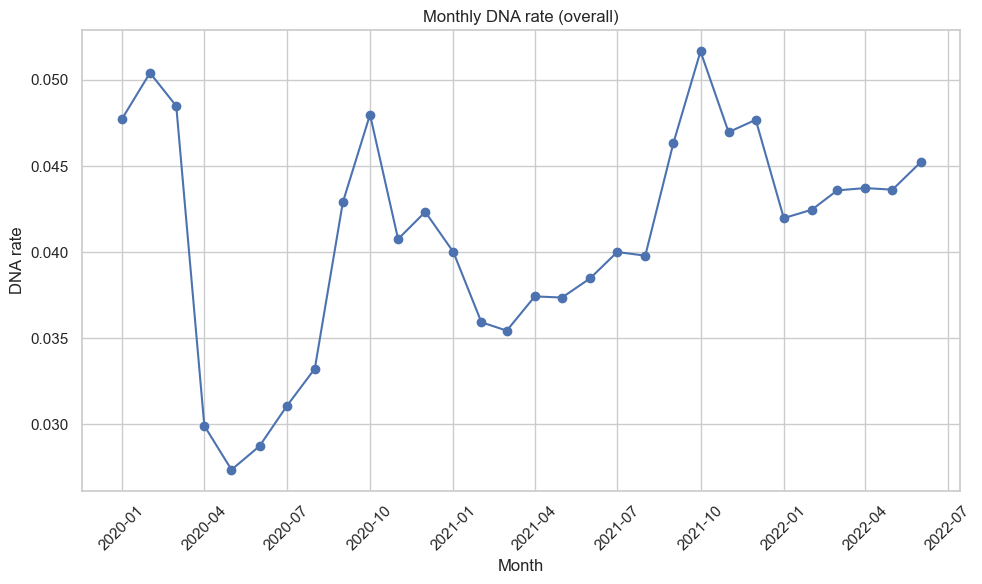

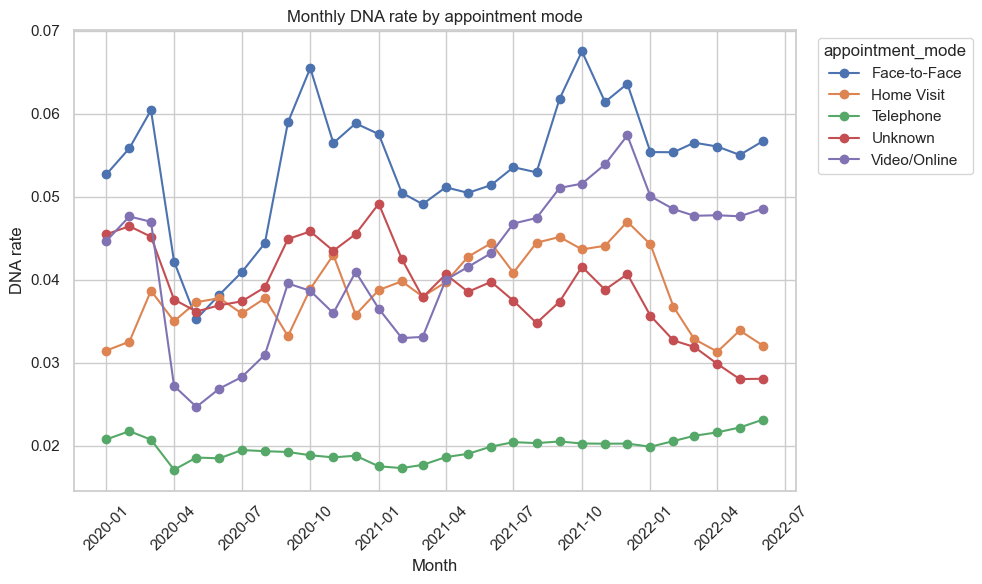

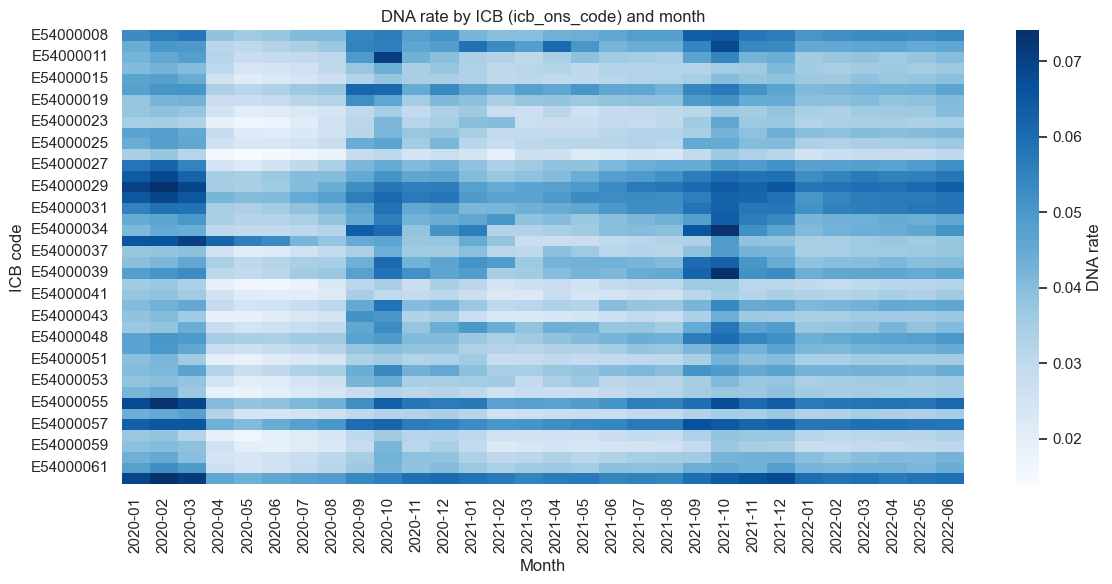

,month,total_appts,dna_appts,dna_rate_percent
0,2020-01-01,27199296,1298269,5
1,2020-02-01,24104621,1215154,5
2,2020-03-01,24053468,1166314,5
3,2020-04-01,16007881,478766,3
4,2020-05-01,16417212,449057,3
5,2020-06-01,20690805,594382,3
6,2020-07-01,22491437,698327,3
7,2020-08-01,20150520,669462,3
8,2020-09-01,26714255,1145971,4
9,2020-10-01,28301932,1358138,5


In [226]:
# What are the trends and patterns in missed appointments
# and how do they affect utilisation

# Data required
# appointments_regional.csv
# actual_duration.csv
# Fields used
# appointment_status
# appointment_month
# appointment_mode
# actual_duration
# count_of_appointments

# Approach
# Compute monthly DNA rates by region and appointment mode
# Identify temporal and seasonal trends
# Estimate lost consultation time using DNA counts
# multiplied by average consultation duration

COL_MONTH  = "appointment_month"
COL_REGION = "icb_ons_code"                
COL_STATUS = "appointment_status"
COL_MODE   = "appointment_mode"
COL_COUNT  = "count_of_appointments"

DNA_LABEL = "DNA"

# -----------------------------
# 1) Clean + standardise month
# -----------------------------
df = ar[[COL_MONTH, COL_REGION, COL_STATUS, COL_MODE, COL_COUNT]].copy()

df[COL_MONTH] = pd.to_datetime(df[COL_MONTH], errors="coerce")
df = df[df[COL_MONTH].notna()].copy()
df["month"] = df[COL_MONTH].dt.to_period("M").dt.to_timestamp()

df[COL_COUNT] = pd.to_numeric(df[COL_COUNT], errors="coerce").fillna(0)
df[COL_STATUS] = df[COL_STATUS].astype(str).str.strip()
df["is_dna"] = df[COL_STATUS].eq(DNA_LABEL)

# -----------------------------
# 2) Overall monthly DNA rate
# -----------------------------
monthly = (
    df.groupby("month", as_index=False)
      .agg(
          total_appts=(COL_COUNT, "sum"),
          dna_appts=(COL_COUNT, lambda s: s[df.loc[s.index, "is_dna"]].sum())
      )
)

monthly["dna_rate"] = np.where(
    monthly["total_appts"] > 0,
    monthly["dna_appts"] / monthly["total_appts"],
    np.nan
)

plt.figure()
plt.plot(monthly["month"], monthly["dna_rate"], marker="o")
plt.title("Monthly DNA rate (overall)")
plt.xlabel("Month")
plt.ylabel("DNA rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 3) DNA rate by appointment_mode
# -----------------------------
mode_monthly = (
    df.groupby(["month", COL_MODE], as_index=False)
      .agg(
          total_appts=(COL_COUNT, "sum"),
          dna_appts=(COL_COUNT, lambda s: s[df.loc[s.index, "is_dna"]].sum())
      )
)

mode_monthly["dna_rate"] = np.where(
    mode_monthly["total_appts"] > 0,
    mode_monthly["dna_appts"] / mode_monthly["total_appts"],
    np.nan
)

plt.figure()
for m in sorted(mode_monthly[COL_MODE].dropna().unique()):
    sub = mode_monthly[mode_monthly[COL_MODE] == m].sort_values("month")
    plt.plot(sub["month"], sub["dna_rate"], marker="o", label=str(m))
plt.title("Monthly DNA rate by appointment mode")
plt.xlabel("Month")
plt.ylabel("DNA rate")
plt.xticks(rotation=45)
plt.legend(title="appointment_mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -----------------------------
# 4) DNA rate heatmap by region x month
# -----------------------------
region_monthly = (
    df.groupby([COL_REGION, "month"], as_index=False)
      .agg(
          total_appts=(COL_COUNT, "sum"),
          dna_appts=(COL_COUNT, lambda s: s[df.loc[s.index, "is_dna"]].sum())
      )
)

region_monthly["dna_rate"] = np.where(
    region_monthly["total_appts"] > 0,
    region_monthly["dna_appts"] / region_monthly["total_appts"],
    np.nan
)

heat = region_monthly.pivot(index=COL_REGION, columns="month", values="dna_rate")

# Clean column labels to YYYY-MM format (remove T00:00:00.000000000)
heat.columns = heat.columns.strftime("%Y-%m")

plt.figure(figsize=(12, 6))
sns.heatmap(heat, cmap="Blues", cbar_kws={"label": "DNA rate"})
plt.title("DNA rate by ICB (icb_ons_code) and month")
plt.xlabel("Month")
plt.ylabel("ICB code")
plt.tight_layout()
plt.show()

summary = monthly[["month", "total_appts", "dna_appts", "dna_rate"]].copy()
summary["dna_rate_percent"] = (summary["dna_rate"] * 100).round(2)
summary = summary.drop(columns=["dna_rate"])
display(summary)

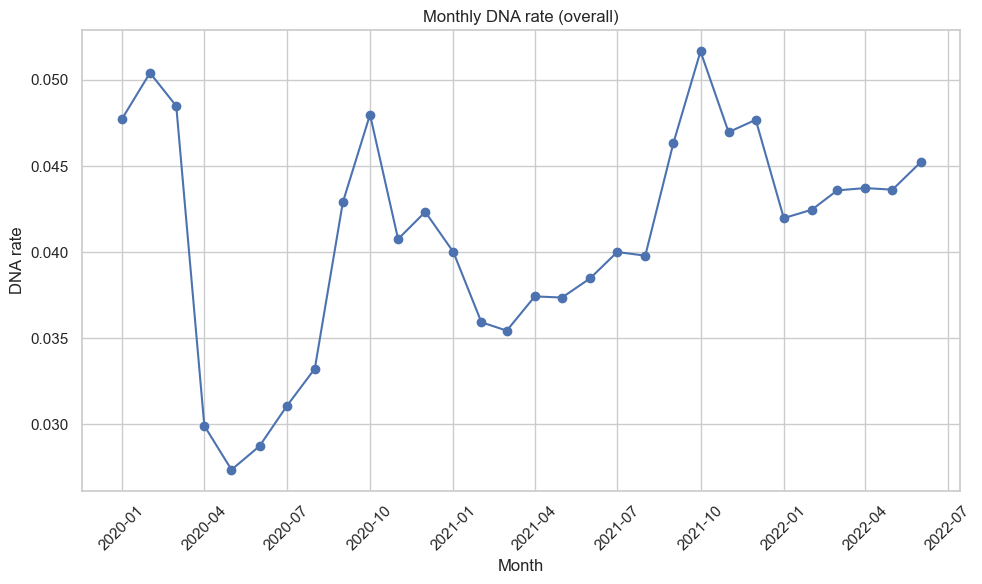

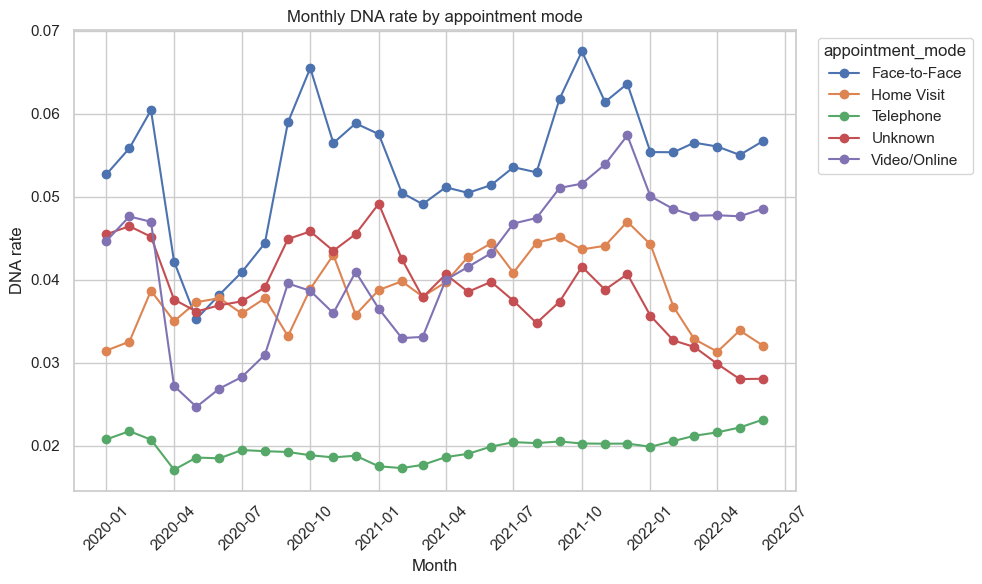

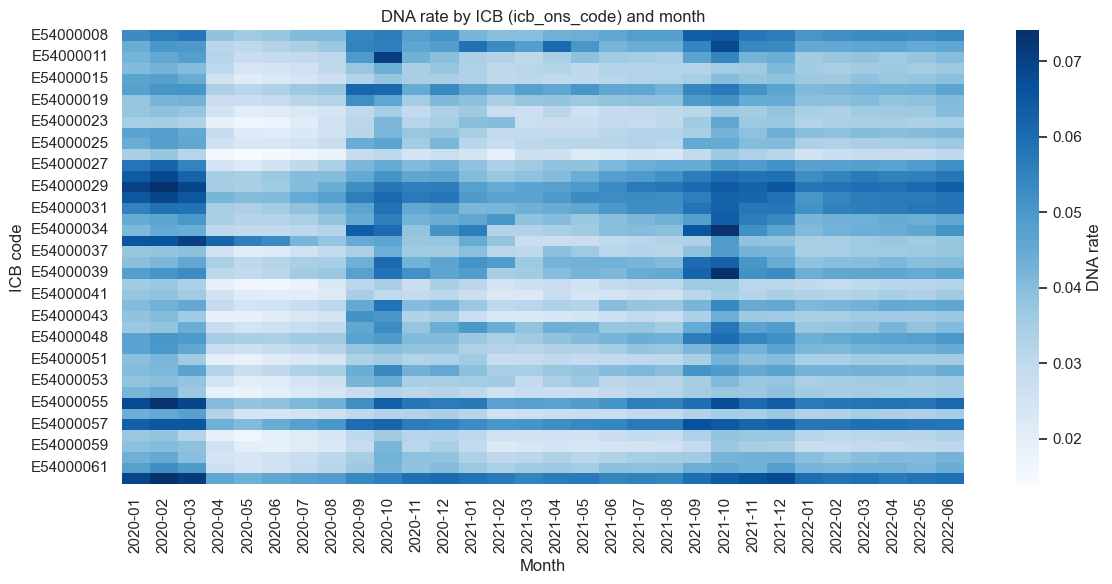

,month,total_appts,dna_appts,dna_rate_percent
0,2020-01-01,27199296,1298269,5
1,2020-02-01,24104621,1215154,5
2,2020-03-01,24053468,1166314,5
3,2020-04-01,16007881,478766,3
4,2020-05-01,16417212,449057,3
5,2020-06-01,20690805,594382,3
6,2020-07-01,22491437,698327,3
7,2020-08-01,20150520,669462,3
8,2020-09-01,26714255,1145971,4
9,2020-10-01,28301932,1358138,5


In [223]:
# What are the trends and patterns in missed appointments
# and how do they affect utilisation

# Data required
# appointments_regional.csv
# actual_duration.csv
# Fields used
# appointment_status
# appointment_month
# appointment_mode
# actual_duration
# count_of_appointments

# Approach
# Compute monthly DNA rates by region and appointment mode
# Identify temporal and seasonal trends
# Estimate lost consultation time using DNA counts
# multiplied by average consultation duration

# helpers, so the code doesn't crash after re-running
def _parse_month_series(s: pd.Series) -> pd.Series:
    s0 = s.copy()

    # numeric formats like 202108 or 20210801
    if pd.api.types.is_numeric_dtype(s0):
        s_str = s0.dropna().astype("Int64").astype(str)

        if len(s_str) > 0 and s_str.str.fullmatch(r"\d{6}").all():
            out = pd.to_datetime(s0.dropna().astype("Int64").astype(str), format="%Y%m", errors="coerce")
            return out.reindex(s0.index)

        if len(s_str) > 0 and s_str.str.fullmatch(r"\d{8}").all():
            out = pd.to_datetime(s0.dropna().astype("Int64").astype(str), format="%Y%m%d", errors="coerce")
            return out.reindex(s0.index)

    # string formats like "2021-08-01", "Aug-21", etc.
    s_str = s0.astype(str).str.strip()
    out = pd.to_datetime(s_str, errors="coerce", infer_datetime_format=True)

    # fallback explicit formats
    if out.notna().sum() == 0:
        out = pd.to_datetime(s_str, format="%b-%y", errors="coerce")     # Aug-21
    if out.notna().sum() == 0:
        out = pd.to_datetime(s_str, format="%B-%y", errors="coerce")     # August-21
    if out.notna().sum() == 0:
        out = pd.to_datetime(s_str, format="%Y-%m", errors="coerce")     # 2021-08

    return out

def _safe_heatmap(df_wide: pd.DataFrame, title: str, xlabel: str, ylabel: str):
    # heatmap fails if all values are NaN (seaborn tries nanmin/nanmax on empty)
    if df_wide.size == 0 or df_wide.notna().sum().sum() == 0:
        plt.figure(figsize=(12, 6))
        plt.text(0.5, 0.5, "Heatmap not available (no DNA rate values)",
                 ha="center", va="center")
        plt.axis("off")
        plt.title(title)
        plt.show()
        return

    plt.figure(figsize=(12, 6))
    sns.heatmap(df_wide, cmap="Blues", cbar_kws={"label": "DNA rate"})
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

# column names 
COL_STATUS = "appointment_status"
COL_MONTH  = "appointment_month"
COL_MODE   = "appointment_mode"
COL_COUNT  = "count_of_appointments"
COL_REGION = "icb_ons_code"  

DNA_LABEL = "DNA"

# sanity check because the code crashed after re-running
required_ar = [COL_STATUS, COL_MONTH, COL_MODE, COL_COUNT, COL_REGION]
missing_ar = [c for c in required_ar if c not in ar.columns]
if missing_ar:
    raise KeyError(f"appointments_regional missing columns: {missing_ar}")

required_ad = ["actual_duration", "count_of_appointments"]
missing_ad = [c for c in required_ad if c not in ad.columns]
if missing_ad:
    raise KeyError(f"actual_duration missing columns: {missing_ad}")

# ---------- 1) clean + standardise month ----------
df = ar[required_ar].copy()

df[COL_MONTH] = _parse_month_series(df[COL_MONTH])
df = df[df[COL_MONTH].notna()].copy()
df["month"] = df[COL_MONTH].dt.to_period("M").dt.to_timestamp()

df[COL_COUNT]  = pd.to_numeric(df[COL_COUNT], errors="coerce").fillna(0)
df[COL_STATUS] = df[COL_STATUS].astype(str).str.strip()
df[COL_MODE]   = df[COL_MODE].astype(str).str.strip()
df[COL_REGION] = df[COL_REGION].astype(str).str.strip()

df["is_dna"] = df[COL_STATUS].str.upper().eq(DNA_LABEL)

# ---------- 2) overall monthly DNA rate ----------
monthly = (
    df.groupby("month", as_index=False)
      .agg(
          total_appts=(COL_COUNT, "sum"),
          dna_appts=(COL_COUNT, lambda s: s[df.loc[s.index, "is_dna"]].sum())
      )
)
monthly["dna_rate"] = np.where(monthly["total_appts"] > 0,
                               monthly["dna_appts"] / monthly["total_appts"],
                               np.nan)

if monthly["dna_rate"].notna().any():
    plt.figure()
    plt.plot(monthly["month"], monthly["dna_rate"], marker="o")
    plt.title("Monthly DNA rate (overall)")
    plt.xlabel("Month")
    plt.ylabel("DNA rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    plt.figure()
    plt.text(0.5, 0.5, "No monthly DNA rate data available", ha="center", va="center")
    plt.axis("off")
    plt.title("Monthly DNA rate (overall)")
    plt.show()

# ---------- 3) DNA rate by appointment mode ----------
mode_monthly = (
    df.groupby(["month", COL_MODE], as_index=False)
      .agg(
          total_appts=(COL_COUNT, "sum"),
          dna_appts=(COL_COUNT, lambda s: s[df.loc[s.index, "is_dna"]].sum())
      )
)
mode_monthly["dna_rate"] = np.where(mode_monthly["total_appts"] > 0,
                                    mode_monthly["dna_appts"] / mode_monthly["total_appts"],
                                    np.nan)

if mode_monthly["dna_rate"].notna().any():
    plt.figure()
    for m in sorted(mode_monthly[COL_MODE].dropna().unique()):
        sub = mode_monthly[mode_monthly[COL_MODE] == m].sort_values("month")
        plt.plot(sub["month"], sub["dna_rate"], marker="o", label=str(m))
    plt.title("Monthly DNA rate by appointment mode")
    plt.xlabel("Month")
    plt.ylabel("DNA rate")
    plt.xticks(rotation=45)
    plt.legend(title="appointment_mode", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    plt.figure()
    plt.text(0.5, 0.5, "No DNA rate data available by mode", ha="center", va="center")
    plt.axis("off")
    plt.title("Monthly DNA rate by appointment mode")
    plt.show()

# ---------- 4) DNA rate heatmap by region x month ----------
region_monthly = (
    df.groupby([COL_REGION, "month"], as_index=False)
      .agg(
          total_appts=(COL_COUNT, "sum"),
          dna_appts=(COL_COUNT, lambda s: s[df.loc[s.index, "is_dna"]].sum())
      )
)
region_monthly["dna_rate"] = np.where(region_monthly["total_appts"] > 0,
                                      region_monthly["dna_appts"] / region_monthly["total_appts"],
                                      np.nan)

heat = region_monthly.pivot(index=COL_REGION, columns="month", values="dna_rate")

# clean column labels to YYYY-MM (no T00:00:00.000000000)
try:
    heat.columns = pd.to_datetime(heat.columns).strftime("%Y-%m")
except Exception:
    heat.columns = heat.columns.astype(str)

_safe_heatmap(
    heat,
    title="DNA rate by ICB (icb_ons_code) and month",
    xlabel="Month",
    ylabel="ICB code"
)

# ---------- 5) estimate lost consultation time (utilisation impact) ----------
# Average duration (minutes) weighted by appointment counts (robust to reruns)
ad_tmp = ad[["actual_duration", "count_of_appointments"]].copy()
ad_tmp["actual_duration"] = pd.to_numeric(ad_tmp["actual_duration"], errors="coerce")
ad_tmp["count_of_appointments"] = pd.to_numeric(ad_tmp["count_of_appointments"], errors="coerce").fillna(0)

ad_tmp = ad_tmp[ad_tmp["actual_duration"].notna()].copy()
avg_duration_min = np.nan
if len(ad_tmp) > 0 and ad_tmp["count_of_appointments"].sum() > 0:
    avg_duration_min = np.average(ad_tmp["actual_duration"], weights=ad_tmp["count_of_appointments"])

# DNA counts per month
dna_by_month = (
    df[df["is_dna"]]
    .groupby("month", as_index=False)
    .agg(dna_appts=(COL_COUNT, "sum"))
)

# join to monthly totals
util = monthly.merge(dna_by_month, on="month", how="left", suffixes=("", "_check"))
util["dna_appts"] = util["dna_appts"].fillna(0)

# ---------- 6) summary table ----------
summary = util[["month", "total_appts", "dna_appts", "dna_rate"]].copy()
summary["dna_rate_percent"] = (summary["dna_rate"] * 100).round(2)
summary = summary.drop(columns=["dna_rate"])
display(summary)


# Assignment activity 2

#### Actual duration dataset

In [209]:
# sense check the data
print("DataFrame shape:")
print(ad.shape)

print("\nColumn names:")
print(ad.columns)

print("\nData types and non null counts:")
print(ad.info())

print("\nDescriptive statistics for numeric columns:")
print(ad.describe())

print("\nData types")
print(ad.dtypes)

print("\nMissing values")
print(ad.isna().sum())

print("\nUnique values")
print(ad.nunique())

print(ad.head())


DataFrame shape:
(137793, 9)

Column names:
Index(['sub_icb_location_code', 'sub_icb_location_ons_code',
       'sub_icb_location_name', 'icb_ons_code', 'region_ons_code',
       'appointment_date', 'actual_duration', 'count_of_appointments',
       'appointment_month'],
      dtype='object')

Data types and non null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 9 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   sub_icb_location_code      137793 non-null  object        
 1   sub_icb_location_ons_code  137793 non-null  object        
 2   sub_icb_location_name      137793 non-null  object        
 3   icb_ons_code               137793 non-null  object        
 4   region_ons_code            137793 non-null  object        
 5   appointment_date           137793 non-null  datetime64[ns]
 6   actual_duration            137793 non-null  ob

#### Appointment regional data set

In [210]:
# sense check the data
print("DataFrame shape:")
print(ar.shape)

print("\nColumn names:")
print(ar.columns)

print("\nData types and non null counts:")
print(ar.info())

print("\nDescriptive statistics for numeric columns:")
print(ar.describe())

print("\nData types")
print(ar.dtypes)

print("\nMissing values")
print(ar.isna().sum())

print("\nUnique values")
print(ar.nunique())

print(ar.head())


DataFrame shape:
(596821, 7)

Column names:
Index(['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type',
       'appointment_mode', 'time_between_book_and_appointment',
       'count_of_appointments'],
      dtype='object')

Data types and non null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype    
---  ------                             --------------   -----    
 0   icb_ons_code                       596821 non-null  object   
 1   appointment_month                  596821 non-null  period[M]
 2   appointment_status                 596821 non-null  object   
 3   hcp_type                           596821 non-null  object   
 4   appointment_mode                   596821 non-null  object   
 5   time_between_book_and_appointment  596821 non-null  object   
 6   count_of_appointments              596821 non-null  int64    
dtypes: int64

In [211]:
# appointments_regional.csv

# ---------------------------------------------------------------------
# How many locations are there in the data set?
# ---------------------------------------------------------------------

num_locations_ar = ar["icb_ons_code"].nunique()

print("Number of Sub ICB locations in appointments_regional dataset:", num_locations_ar)

# ---------------------------------------------------------------------
# What are the five locations with the highest number of appointments?
# ---------------------------------------------------------------------
top_5_locations_ar = (
    ar
    .groupby("icb_ons_code")["count_of_appointments"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 locations by total number of appointments in appointments_regional:")
print(top_5_locations_ar)

# ---------------------------------------------------------------------
# How many service settings, context types, national categories, and appointment statuses are there?
# ---------------------------------------------------------------------

# this data set does not include information about service settinga, context types, national categories

# appointment statuses
ar["appointment_status"].nunique()
ar["appointment_status"].value_counts()

# ---------------------------------------------------------------------
# Are there any comments regarding data quality or descriptive statistics worth noting for each of the data sets?
# ---------------------------------------------------------------------

# The appointments_regional dataset is aggregated at a monthly level rather than daily. 
# This limits fine grained temporal analysis but is appropriate for identifying medium term and seasonal trends.

# The appointment_status column includes an Unknown category.
# This represents appointments that remained Booked at the time of reporting and does not necessarily indicate missing data.

# DNA appointments are known to be under reported for part of the historical period due to data collection issues. 
# This should be considered when interpreting missed appointment trends

# The hcp_type field is simplified. Only GP appointments are consistently recorded while all other healthcare professional
# roles are grouped under Other Practice Staff. 
# This limits detailed workforce analysis.

# ---------------------------------------------------------------------
# Can you comment on other features (columns) that could potentially be useful in your analysis?
# ---------------------------------------------------------------------

# The icb_ons_code column defines the geographic unit of analysis
# at Integrated Care Board level and allows comparison of
# appointment utilisation across regions.

# The appointment_month column enables time based analysis
# including identification of trends and seasonal patterns
# in appointment volumes.

# The appointment_status column is central to analysing missed
# appointments and potential inefficiencies in utilisation
# through categories such as Attended DNA and Unknown.

# The appointment_mode column allows comparison of different
# delivery methods such as face to face and telephone
# which may have implications for capacity and efficiency.

# The time_between_book_and_appointment column provides
# information on access delays and booking behaviour and
# can be used as a proxy for demand pressure.

# The hcp_type column enables a high level comparison between
# GP delivered activity and activity delivered by other
# practice staff although detailed workforce analysis is
# limited by aggregation.



Number of Sub ICB locations in appointments_regional dataset: 42
Top 5 locations by total number of appointments in appointments_regional:
icb_ons_code
E54000050    43083535
E54000054    36090387
E54000057    34080583
E54000008    33099882
E54000027    29380767
Name: count_of_appointments, dtype: int64


appointment_status
Attended    232137
Unknown     201324
DNA         163360
Name: count, dtype: int64

#### National categories data set 

In [212]:
# sense check the data
print("DataFrame shape:")
print(nc.shape)

print("\nColumn names:")
print(nc.columns)

print("\nData types and non null counts:")
print(nc.info())

print("\nDescriptive statistics for numeric columns:")
print(nc.describe())

print("\nData types")
print(nc.dtypes)

print("\nMissing values")
print(nc.isna().sum())

print("\nUnique values")
print(nc.nunique())

print(nc.head())


DataFrame shape:
(817394, 8)

Column names:
Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month'],
      dtype='object')

Data types and non null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
dtypes

In [7]:
# national_categories.xlsx

# ---------------------------------------------------------------------
# How many locations are there in the data set?
# ---------------------------------------------------------------------

num_locations_nc = nc["icb_ons_code"].nunique()

print("Number of Sub ICB locations in national_categories dataset:", num_locations_nc)

# ---------------------------------------------------------------------
# What are the five locations with the highest number of appointments?
# ---------------------------------------------------------------------
top_5_locations_nc = (
    nc
    .groupby("sub_icb_location_name")["count_of_appointments"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 locations by total number of appointments in appointments_regional:")
print(top_5_locations_nc)

# ---------------------------------------------------------------------
# How many service settings, context types, national categories, and appointment statuses are there?
# ---------------------------------------------------------------------

# This question is answered by counting the number of unique values
# in the relevant categorical columns present in the dataset.

# The national_categories dataset contains service_setting, context_type, national_category
# It does not contain appointment_status, so appointment statuses are not applicable for this dataset.

service_settings = nc["service_setting"].dropna().unique()
context_types = nc["context_type"].dropna().unique()
national_categories = nc["national_category"].dropna().unique()

print("Service settings count:", len(service_settings))
print("Service settings list:")
print(service_settings)

print("\nContext types count:", len(context_types))
print("Context types list:")
print(context_types)

print("\nNational categories count:", len(national_categories))
print("National categories list:")
print(national_categories)

print("\nAppointment status is not available in the national_categories dataset")


# ---------------------------------------------------------------------
# Are there any comments regarding data quality or descriptive statistics worth noting for each of the data sets?
# ---------------------------------------------------------------------

# The data is aggregated and not recorded at individual appointment level.
# Each row represents a grouped count of appointments by location,
# service setting, context type, and national category.
#
# A non trivial proportion of records fall under the Unmapped service setting
# and Unmapped or Inconsistent Mapping context types.
# This indicates variability in how practices classify appointments
# and suggests limitations in cross practice comparability.
#
# National categories include a Does Not Fit option and Inconsistent Mapping,
# which further highlights classification ambiguity in real world data entry.
#
# Counts represent estimated appointment totals rather than exact figures,
# as not all practices are included in the source data.
# Therefore absolute appointment numbers should be interpreted cautiously,
# while relative comparisons across categories and locations are more reliable.
#
# The dataset is suitable for identifying high level utilisation patterns,
# service mix differences, and regional variation,
# but not for precise capacity or demand estimation at practice level.

# ---------------------------------------------------------------------
# Can you comment on other features (columns) that could potentially be useful in your analysis?
# ---------------------------------------------------------------------

# The appointment_month column allows aggregation and comparison of
# appointment activity over time and supports the analysis of seasonal
# and monthly trends in service utilisation.
#
# The service_setting column is critical for distinguishing where care
# is delivered, such as General Practice, Primary Care Network, or
# Extended Access Provision, which is essential for assessing capacity
# distribution across the NHS network.
#
# The context_type column helps separate direct patient care activity
# from unmapped or inconsistently classified activity, enabling the
# identification of data quality limitations and meaningful clinical use.
#
# The national_category column provides detailed insight into the type
# of clinical activity delivered, such as general consultations,
# planned clinics, or clinical triage, which can be used to identify
# services driving demand and potential pressure points.
#
# The sub_icb_location_name and icb_ons_code columns enable geographic
# comparisons across regions and support the identification of areas
# with higher utilisation or distinctive service mixes.
#
# The count_of_appointments column is the primary quantitative measure
# used throughout the analysis and forms the basis for all utilisation
# comparisons and trend assessments.


Number of Sub ICB locations in national_categories dataset: 42
Top 5 locations by total number of appointments in appointments_regional:
sub_icb_location_name
NHS North West London ICB - W2U3Z              12142390
NHS North East London ICB - A3A8R               9588891
NHS Kent and Medway ICB - 91Q                   9286167
NHS Hampshire and Isle Of Wight ICB - D9Y0V     8288102
NHS South East London ICB - 72Q                 7850170
Name: count_of_appointments, dtype: int64
Service settings count: 5
Service settings list:
['Primary Care Network' 'Other' 'General Practice' 'Unmapped'
 'Extended Access Provision']

Context types count: 3
Context types list:
['Care Related Encounter' 'Unmapped' 'Inconsistent Mapping']

National categories count: 18
National categories list:
['Patient contact during Care Home Round' 'Planned Clinics' 'Home Visit'
 'General Consultation Acute' 'Structured Medication Review'
 'Care Home Visit' 'Unmapped' 'Clinical Triage'
 'Planned Clinical Procedure' 'Inc

#### Tweets data set 

In [127]:
# sense check the data
print("DataFrame shape:")
print(tweets.shape)

print("\nColumn names:")
print(tweets.columns)

print("\nData types and non null counts:")
print(tweets.info())

print("\nDescriptive statistics for numeric columns:")
print(tweets.describe())

print("\nData types")
print(tweets.dtypes)

print("\nMissing values")
print(tweets.isna().sum())

print("\nUnique values")
print(tweets.nunique())

print(tweets.head())


DataFrame shape:
(1174, 10)

Column names:
Index(['tweet_id', 'tweet_full_text', 'tweet_entities',
       'tweet_entities_hashtags', 'tweet_metadata', 'tweet_retweet_count',
       'tweet_favorite_count', 'tweet_favorited', 'tweet_retweeted',
       'tweet_lang'],
      dtype='object')

Data types and non null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null

In [8]:
# tweets.csv

# ---------------------------------------------------------------------
# How many locations are there in the data set?
# ---------------------------------------------------------------------

# none

# ---------------------------------------------------------------------
# What are the five locations with the highest number of appointments?
# ---------------------------------------------------------------------

# none

# ---------------------------------------------------------------------
# How many service settings, context types, national categories, and appointment statuses are there?
# ---------------------------------------------------------------------

# none

# ---------------------------------------------------------------------
# Are there any comments regarding data quality or descriptive statistics worth noting for each of the data sets?
# ---------------------------------------------------------------------

# The tweets dataset is unstructured and subject to typical social media
# data quality limitations. Tweet text and hashtags may be ambiguous,
# sarcastic, or context dependent. Engagement metrics such as retweets
# and likes are highly skewed and may overrepresent a small number of
# highly visible posts. The dataset reflects public discussion and
# sentiment rather than direct measures of healthcare utilisation.

# ---------------------------------------------------------------------
# Can you comment on other features (columns) that could potentially be useful in your analysis?
# ---------------------------------------------------------------------

# Useful features in the tweets dataset include hashtags for identifying
# frequently discussed healthcare topics, tweet timestamps for aligning
# discussion trends with NHS appointment data, and engagement metrics
# such as retweets and likes as indicators of issue visibility and public
# attention. These features can provide contextual insight alongside
# operational NHS metrics.


# Assignment activity 3

### Continue to explore the data and search for answers to more specific questions posed by the NHS.

**Question 1:** Between what dates were appointments scheduled? 

In [19]:
# View the first five rows of appointment_date for the ad DataFrame to determine the date format.

ad['appointment_date'] = pd.to_datetime(ad['appointment_date'])
ad['appointment_date'].head()
ad.dtypes

start_date = ad['appointment_date'].min()
end_date = ad['appointment_date'].max()

print("Appointments were schedules between ", start_date.date(), " and ", end_date.date())


Appointments were schedules between  2021-12-01  and  2022-06-30


In [20]:
# View the first five rows of appointment_date for the nc DataFrame to determine the date format.

nc['appointment_date'].head()


0   2021-08-02
1   2021-08-02
2   2021-08-02
3   2021-08-02
4   2021-08-02
Name: appointment_date, dtype: datetime64[ns]

In [21]:
# Change the date format of ad['appointment_date'].
ad['appointment_date'] = pd.to_datetime(ad['appointment_date'])

# View the DateFrame.
ad.head()

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments,appointment_month
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,31-60 Minutes,364,2021-12
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,21-30 Minutes,619,2021-12
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,6-10 Minutes,1698,2021-12
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,Unknown / Data Quality,1277,2021-12
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,16-20 Minutes,730,2021-12


In [22]:
# Change the date format of ar['appointment_date'].

ar['appointment_date'] = pd.to_datetime(ad['appointment_date'])

# View the DateFrame.
ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,appointment_date
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107,2021-12-01
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791,2021-12-01
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686,2021-12-01
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268,2021-12-01
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971,2021-12-01


**Question 2:** Which service setting was the most popular for NHS North West London from 1 January to 1 June 2022?

In [23]:
# For each of these service settings, determine the number of records available for the period and the location. 
nc.head()
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'])
start = '2022-01-01'
end = '2022-06-01'
nc_subset = nc.loc[
    (nc['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z') &
     (nc['appointment_date'] >= start) &
     (nc['appointment_date'] <= end),
     ['service_setting', 'count_of_appointments', 'appointment_date', 'sub_icb_location_name']]

# View the output.
nc_subset.head()

print("Number of service settings:", nc_subset['service_setting'].nunique())
print("Service settings:", nc_subset['service_setting'].unique())

service_totals = (
    nc_subset
        .groupby('service_setting')['count_of_appointments']
        .sum()
        .sort_values(ascending=False)
)

service_totals

Number of service settings: 5
Service settings: ['Unmapped' 'Primary Care Network' 'Other' 'General Practice'
 'Extended Access Provision']


service_setting
General Practice             4804239
Unmapped                      391106
Other                         152897
Primary Care Network          109840
Extended Access Provision      98159
Name: count_of_appointments, dtype: int64

**Question 3:** Which month had the highest number of appointments?

In [24]:
# Number of appointments per month == sum of count_of_appointments by month.
# Use the groupby() and sort_values() functions.
appointments_per_month = (
    ar
    .groupby('appointment_month')['count_of_appointments']
    .sum()
    .sort_values(ascending=False)
)

top_month = appointments_per_month.index[0]
top_count = appointments_per_month.iloc[0]

print(f"Month with the highest number of appointments is {top_month} with {top_count:,} appointments.")

Month with the highest number of appointments is 2021-11 with 30,405,070 appointments.


**Question 4:** What was the total number of records per month?

In [25]:
# Total number of records per month
records_per_month = (
    nc.
    groupby('appointment_month')['count_of_appointments']
    .sum()
    .sort_values(ascending=False)
)
records_per_month.head()


appointment_month
2021-11    30405070
2021-10    30303834
2022-03    29595038
2021-09    28522501
2022-05    27495508
Name: count_of_appointments, dtype: int64

# Assignment activity 4

### Create visualisations and identify possible monthly and seasonal trends in the data.

In [128]:
# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

### Objective 1
Create three visualisations indicating the number of appointments per month for service settings, context types, and national categories.

In [129]:
# Change the data type of the appointment month to string to allow for easier plotting.

nc['appointment_month'] = nc['appointment_month'].astype('str')
nc.dtypes

appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month                object
season                           object
dtype: object

In [130]:
# Aggregate on monthly level and determine the sum of records per month.
# new dataframe with the sum of appointments per month by service setting 
nc_ss = (
    nc.groupby(['appointment_month', 'service_setting'], as_index=False)['count_of_appointments']
               .sum()
)

# View output.
nc_ss.head()


,appointment_month,service_setting,count_of_appointments
0,2021-08,Extended Access Provision,160927
1,2021-08,General Practice,21575852
2,2021-08,Other,449101
3,2021-08,Primary Care Network,432448
4,2021-08,Unmapped,1233843


**Service settings:**

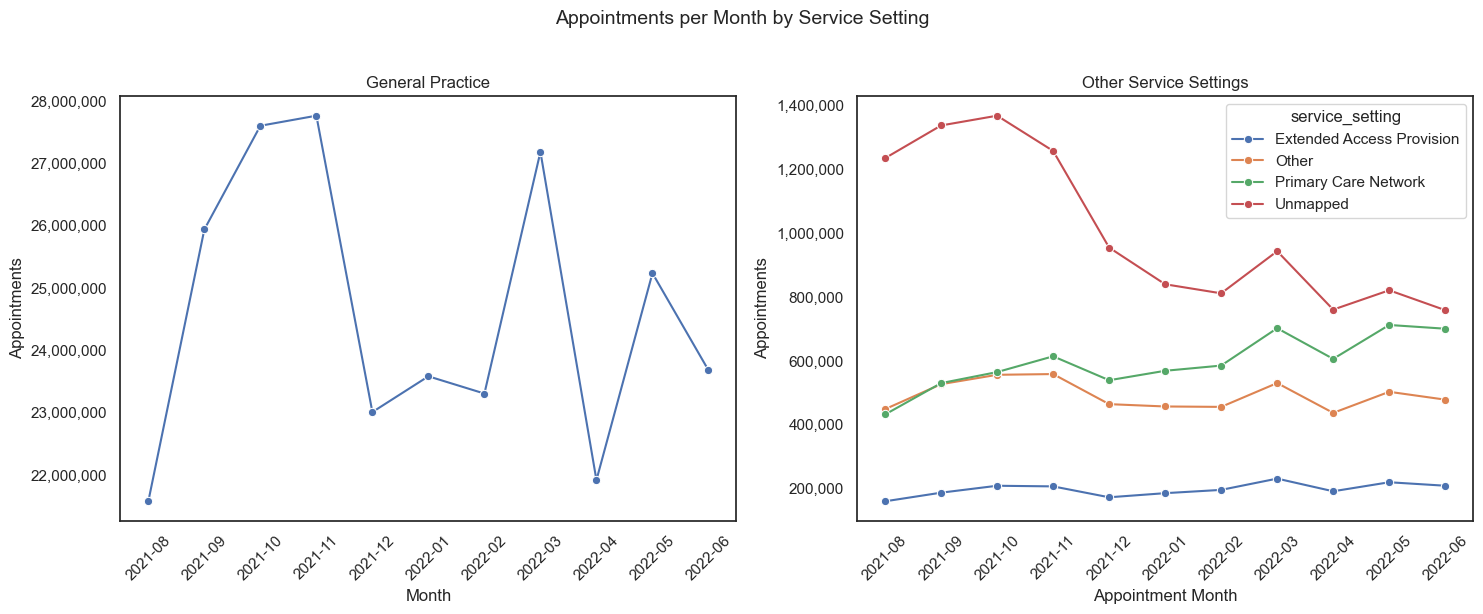

In [131]:
# Plot the appointments over the available date range, and review the service settings for months.
# Create side-by-side subplots: dominant category (GP) vs the rest.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

# Left panel: General Practice (dominant)
ss_gp = nc_ss[nc_ss['service_setting'] == 'General Practice']
sns.lineplot(
    x='appointment_month',
    y='count_of_appointments',
    data=ss_gp,
    ax=ax1,
    marker='o',
    errorbar=None
)
ax1.set_title('General Practice')
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax1.set_xlabel('Month')
ax1.set_ylabel('Appointments')
ax1.tick_params(axis='x', rotation=45)

# Right panel: all other service settings
ss_other = nc_ss[nc_ss['service_setting'] != 'General Practice']
sns.lineplot(
    x='appointment_month',
    y='count_of_appointments',
    hue='service_setting',
    data=ss_other,
    ax=ax2,
    marker='o',
    errorbar=None
)
ax2.set_title('Other Service Settings')
ax2.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax2.set_xlabel('Appointment Month')
ax2.set_ylabel('Appointments')
ax2.tick_params(axis='x', rotation=45)

fig.suptitle('Appointments per Month by Service Setting', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Context types:**

In [132]:
# Create a separate data set that can be used in future weeks. 

nc_ct = (
    nc.groupby(['appointment_month', 'context_type'], as_index=False)['count_of_appointments']
               .sum()
)
# View output.
nc_ct.head()

,appointment_month,context_type,count_of_appointments
0,2021-08,Care Related Encounter,20255235
1,2021-08,Inconsistent Mapping,2363093
2,2021-08,Unmapped,1233843
3,2021-09,Care Related Encounter,24404251
4,2021-09,Inconsistent Mapping,2782135


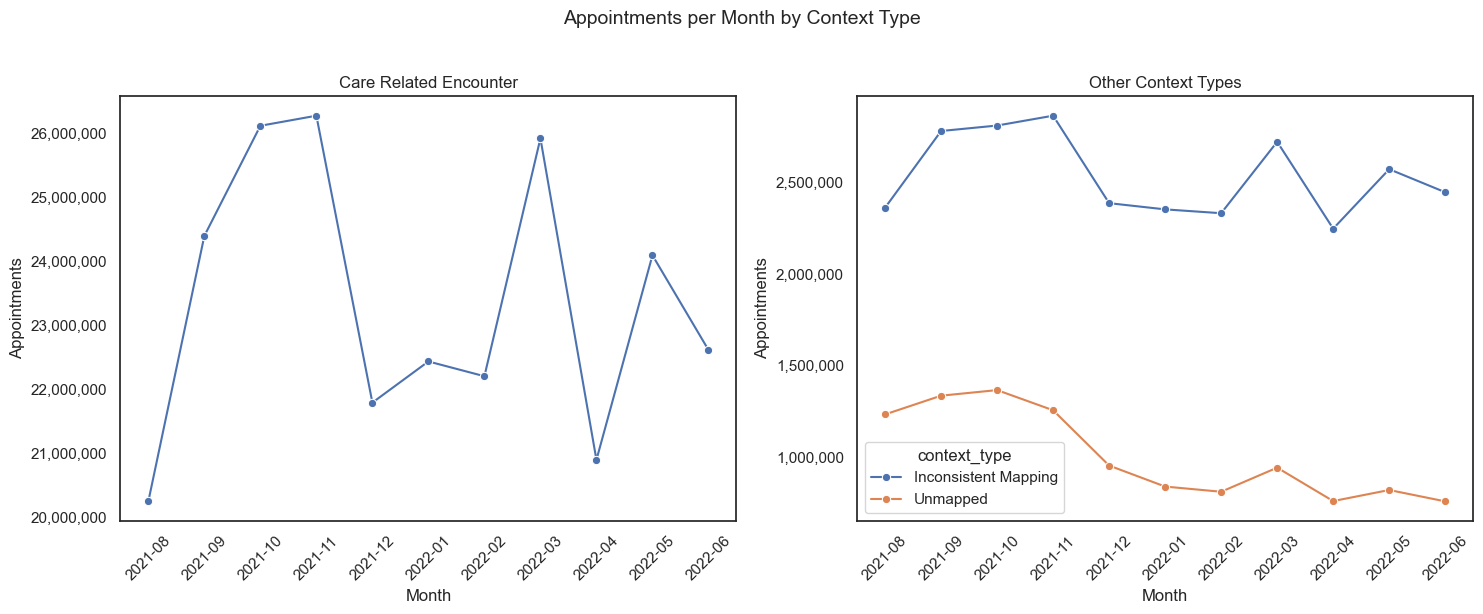

In [133]:
# Plot the appointments over the available date range, and review the context types for months.
# Create side-by-side subplots: dominant category vs the rest.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

# Left panel: Care Related Encounter (dominant)
ct_dominant = nc_ct[nc_ct['context_type'] == 'Care Related Encounter']
sns.lineplot(
    x='appointment_month',
    y='count_of_appointments',
    data=ct_dominant,
    ax=ax1,
    marker='o',
    errorbar=None
)
ax1.set_title('Care Related Encounter')
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax1.set_xlabel('Month')
ax1.set_ylabel('Appointments')
ax1.tick_params(axis='x', rotation=45)

# Right panel: remaining context types
ct_other = nc_ct[nc_ct['context_type'] != 'Care Related Encounter']
sns.lineplot(
    x='appointment_month',
    y='count_of_appointments',
    hue='context_type',
    data=ct_other,
    ax=ax2,
    marker='o',
    errorbar=None
)
ax2.set_title('Other Context Types')
ax2.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax2.set_xlabel('Month')
ax2.set_ylabel('Appointments')
ax2.tick_params(axis='x', rotation=45)

fig.suptitle('Appointments per Month by Context Type', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**National categories:**

In [134]:
# Create a separate data set that can be used in future weeks. 

nc_nc = (
    nc.groupby(['appointment_month', 'national_category'], as_index = False)['count_of_appointments']
    .sum()
)
# View output.
nc_nc.head()

,appointment_month,national_category,count_of_appointments
0,2021-08,Care Home Needs Assessment & Personalised Care and Support Planning,29676
1,2021-08,Care Home Visit,47583
2,2021-08,Clinical Triage,3704207
3,2021-08,General Consultation Acute,4280920
4,2021-08,General Consultation Routine,7756045


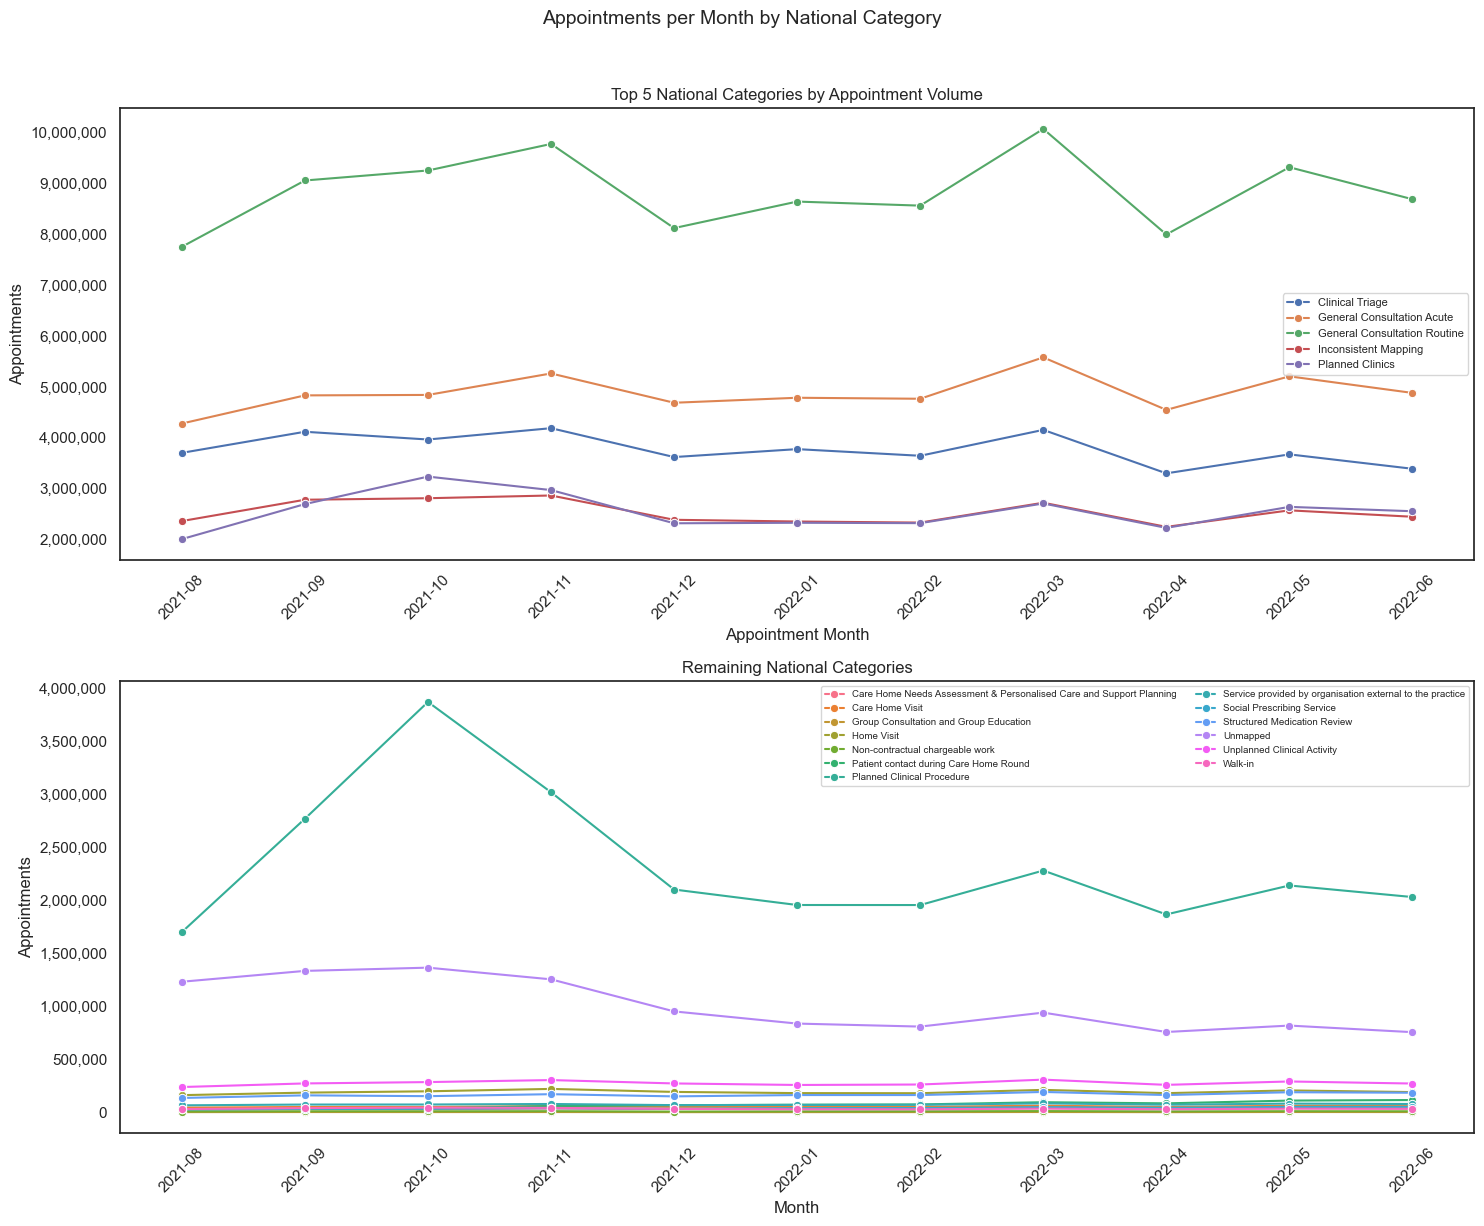

In [135]:
# Plot the appointments over the available date range, and review the national categories for months.
# Identify the top 5 categories by total volume.
top_categories = (
    nc_nc.groupby('national_category')['count_of_appointments']
    .sum()
    .nlargest(5)
    .index
    .tolist()
)

# Create stacked subplots: top 5 vs remaining categories.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharey=False)

# Top panel: top 5 national categories
nc_top = nc_nc[nc_nc['national_category'].isin(top_categories)]
sns.lineplot(
    x='appointment_month',
    y='count_of_appointments',
    hue='national_category',
    data=nc_top,
    ax=ax1,
    marker='o',
    errorbar=None
)
ax1.set_title('Top 5 National Categories by Appointment Volume')
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax1.set_xlabel('Appointment Month')
ax1.set_ylabel('Appointments')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=8)

# Bottom panel: remaining national categories
nc_rest = nc_nc[~nc_nc['national_category'].isin(top_categories)]
sns.lineplot(
    x='appointment_month',
    y='count_of_appointments',
    hue='national_category',
    data=nc_rest,
    ax=ax2,
    marker='o',
    errorbar=None
)
ax2.set_title('Remaining National Categories')
ax2.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax2.set_xlabel('Month')
ax2.set_ylabel('Appointments')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=7, ncol=2)

fig.suptitle('Appointments per Month by National Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Objective 2
Create four visualisations indicating the number of appointments for service setting per season. The seasons are summer (June to August 2021), autumn (September to November 2021), winter (December to February 2022), and spring (March to May 2022).

**Summer (June to August 2021):**

In [136]:
# Create seasonal DataFrames for Objective 2.
# Map each appointment_month to a season as defined by the assignment.
season_map = {
    '2021-06': 'Summer', '2021-07': 'Summer', '2021-08': 'Summer',
    '2021-09': 'Autumn', '2021-10': 'Autumn', '2021-11': 'Autumn',
    '2021-12': 'Winter', '2022-01': 'Winter', '2022-02': 'Winter',
    '2022-03': 'Spring', '2022-04': 'Spring', '2022-05': 'Spring',
}
nc['season'] = nc['appointment_month'].map(season_map)

# Aggregate total appointments per service setting per season.
# This sums across all months within each season.
nc_season = (
    nc[nc['season'].notna()]
    .groupby(['season', 'service_setting'], as_index=False)['count_of_appointments']
    .sum()
)

# Create individual seasonal DataFrames.
nc_summer = nc_season[nc_season['season'] == 'Summer'].copy()
nc_autumn = nc_season[nc_season['season'] == 'Autumn'].copy()
nc_winter = nc_season[nc_season['season'] == 'Winter'].copy()
nc_spring = nc_season[nc_season['season'] == 'Spring'].copy()

# View output.
print('Summer (Aug 2021 only):')
print(nc_summer[['service_setting', 'count_of_appointments']].to_string(index=False))
print(f'\nAutumn (Sep–Nov 2021):')
print(nc_autumn[['service_setting', 'count_of_appointments']].to_string(index=False))
print(f'\nWinter (Dec 2021–Feb 2022):')
print(nc_winter[['service_setting', 'count_of_appointments']].to_string(index=False))
print(f'\nSpring (Mar–May 2022):')
print(nc_spring[['service_setting', 'count_of_appointments']].to_string(index=False))

Summer (Aug 2021 only):
          service_setting  count_of_appointments
Extended Access Provision                 160927
         General Practice               21575852
                    Other                 449101
     Primary Care Network                 432448
                 Unmapped                1233843

Autumn (Sep–Nov 2021):
          service_setting  count_of_appointments
Extended Access Provision                 605022
         General Practice               81314881
                    Other                1642445
     Primary Care Network                1709790
                 Unmapped                3959267

Winter (Dec 2021–Feb 2022):
          service_setting  count_of_appointments
Extended Access Provision                 556506
         General Practice               69897805
                    Other                1378311
     Primary Care Network                1693823
                 Unmapped                2605065

Spring (Mar–May 2022):
          service

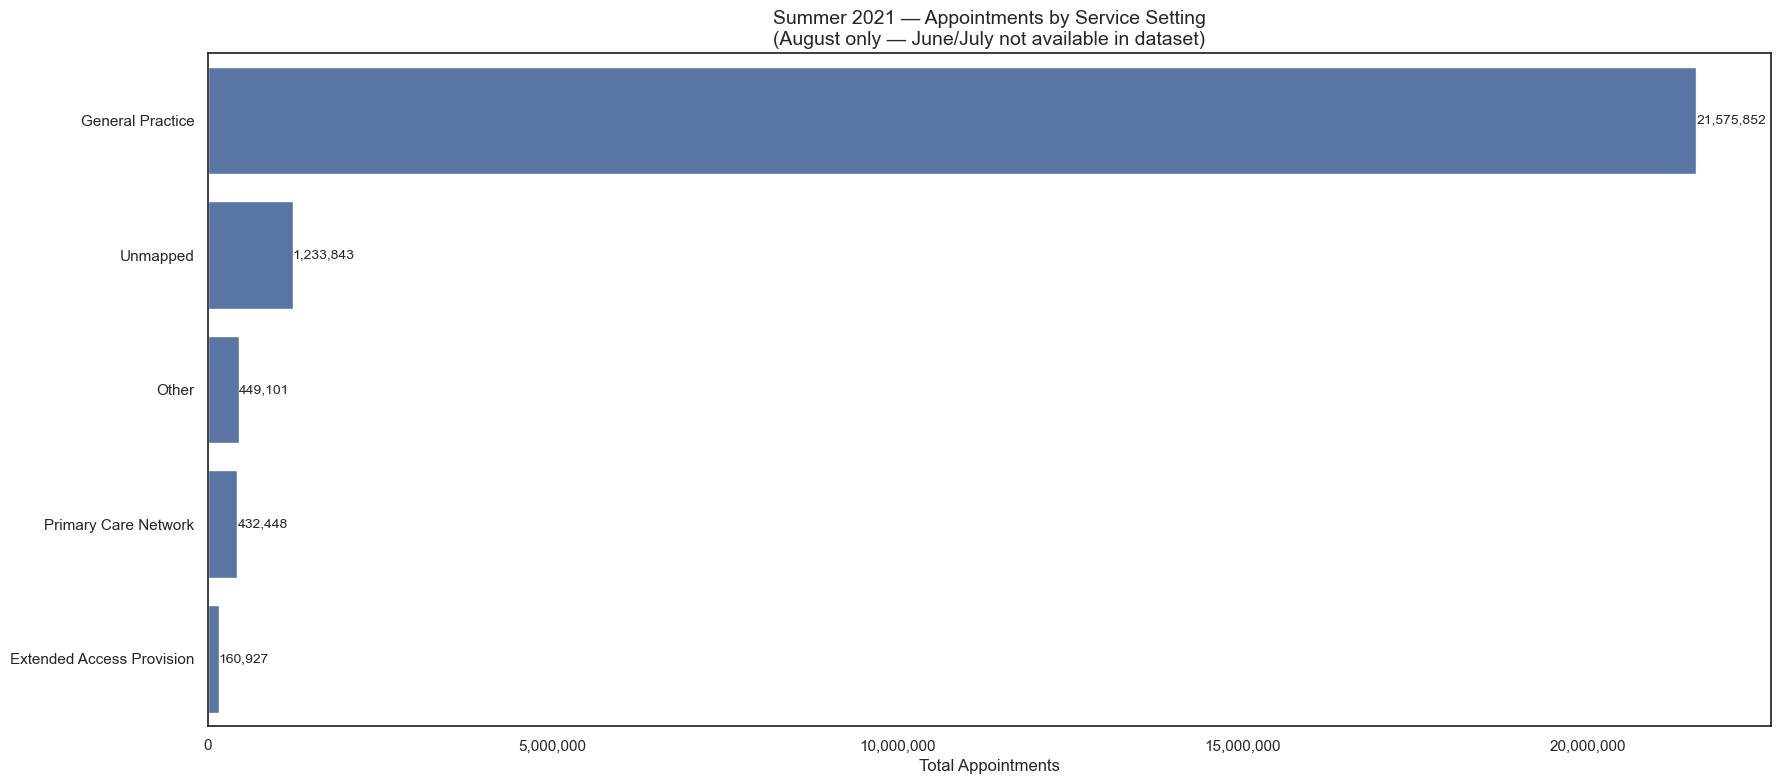

In [137]:
# Summer 2021 — horizontal bar chart of total appointments by service setting.
# Note: Only August 2021 data is available (June/July not in the dataset).
fig, ax = plt.subplots(figsize=(18, 8))

sns.barplot(x='count_of_appointments', y='service_setting',
            data=nc_summer.sort_values('count_of_appointments', ascending=False),
            ax=ax, order=nc_summer.sort_values('count_of_appointments', ascending=False)['service_setting'])
ax.set_title('Summer 2021 — Appointments by Service Setting\n(August only — June/July not available in dataset)',
             fontsize=14)
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.set_xlabel('Total Appointments')
ax.set_ylabel('')

for p in ax.patches:
    ax.annotate(f'{p.get_width():,.0f}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Autumn (September to November 2021):**

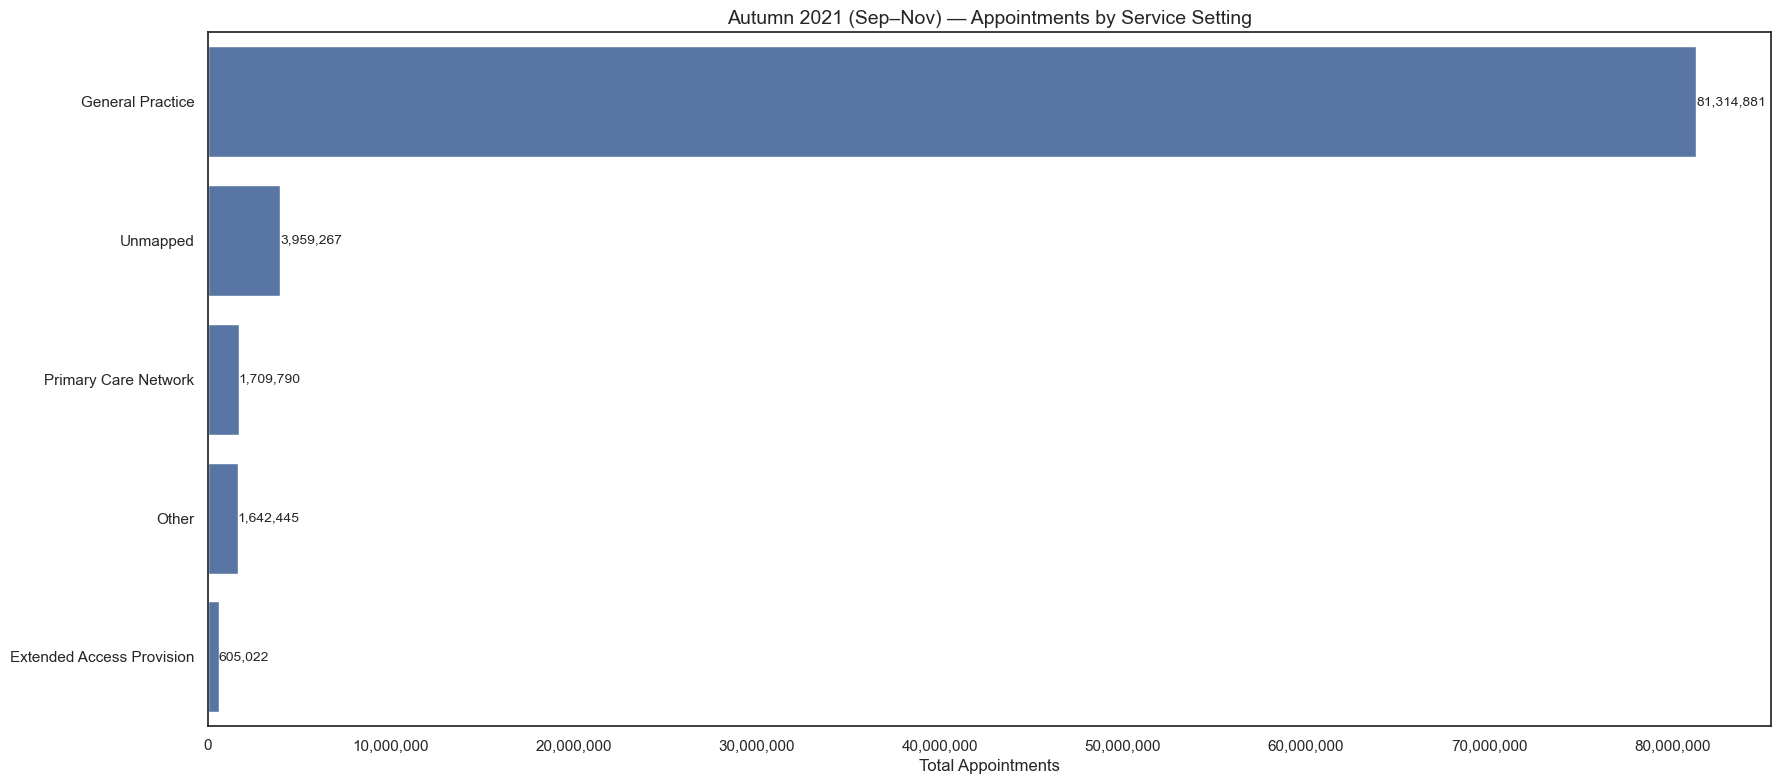

In [138]:
# Autumn 2021 (Sep–Nov) — horizontal bar chart of total appointments by service setting.
fig, ax = plt.subplots(figsize=(18, 8))

sns.barplot(x='count_of_appointments', y='service_setting',
            data=nc_autumn.sort_values('count_of_appointments', ascending=False),
            ax=ax, order=nc_autumn.sort_values('count_of_appointments', ascending=False)['service_setting'])
ax.set_title('Autumn 2021 (Sep–Nov) — Appointments by Service Setting', fontsize=14)
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.set_xlabel('Total Appointments')
ax.set_ylabel('')

for p in ax.patches:
    ax.annotate(f'{p.get_width():,.0f}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Winter (December to February 2022):**

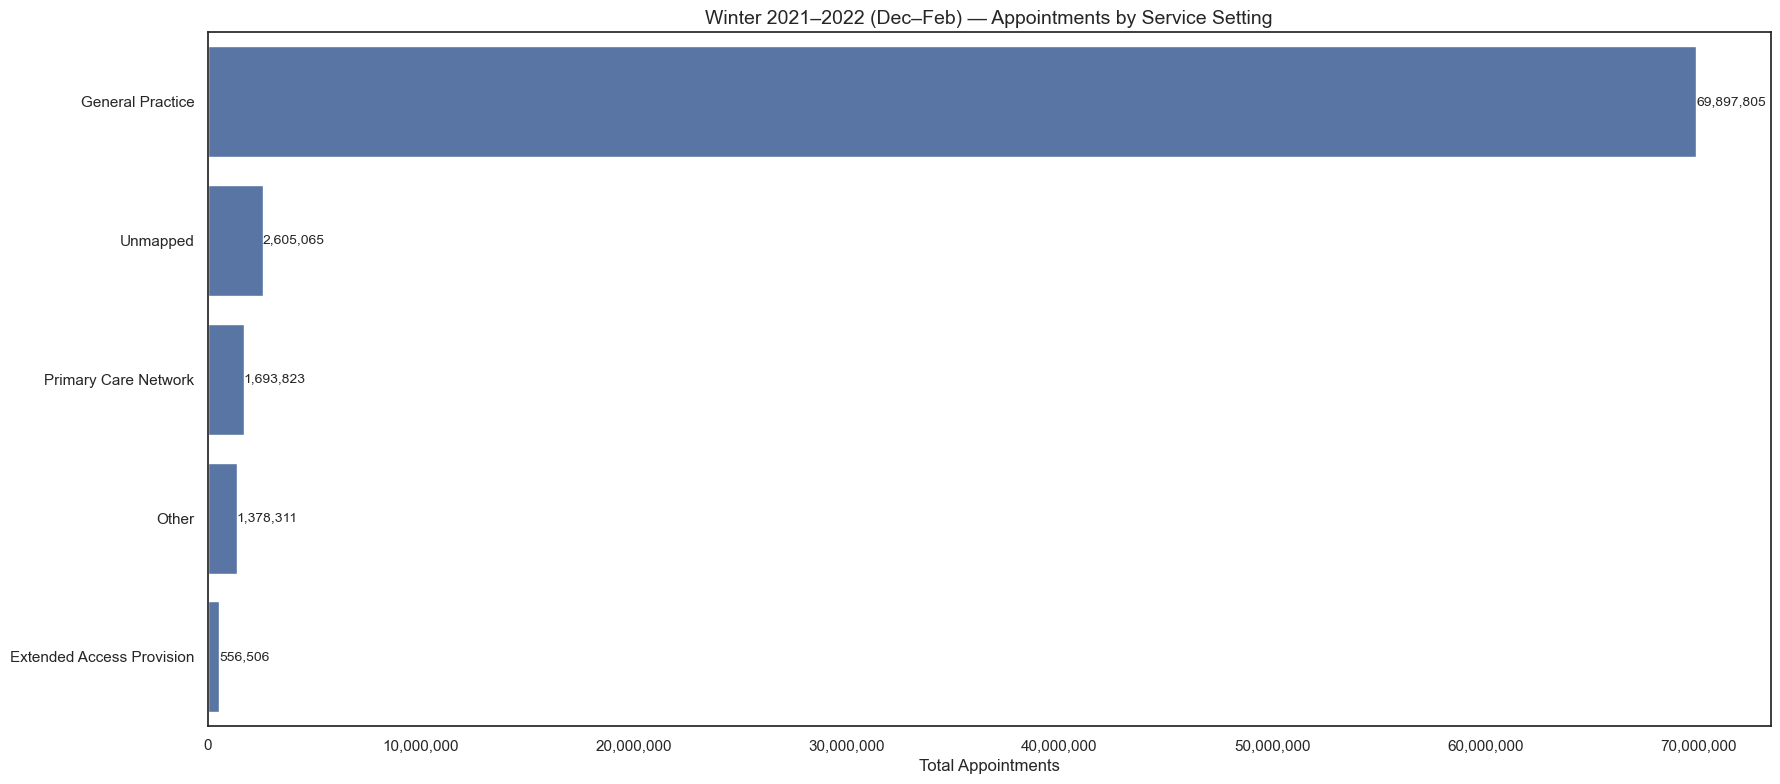

In [139]:
# Winter 2021–2022 (Dec–Feb) — horizontal bar chart of total appointments by service setting.
fig, ax = plt.subplots(figsize=(18, 8))

sns.barplot(x='count_of_appointments', y='service_setting',
            data=nc_winter.sort_values('count_of_appointments', ascending=False),
            ax=ax, order=nc_winter.sort_values('count_of_appointments', ascending=False)['service_setting'])
ax.set_title('Winter 2021–2022 (Dec–Feb) — Appointments by Service Setting', fontsize=14)
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.set_xlabel('Total Appointments')
ax.set_ylabel('')

for p in ax.patches:
    ax.annotate(f'{p.get_width():,.0f}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Spring (March to May 2022):**

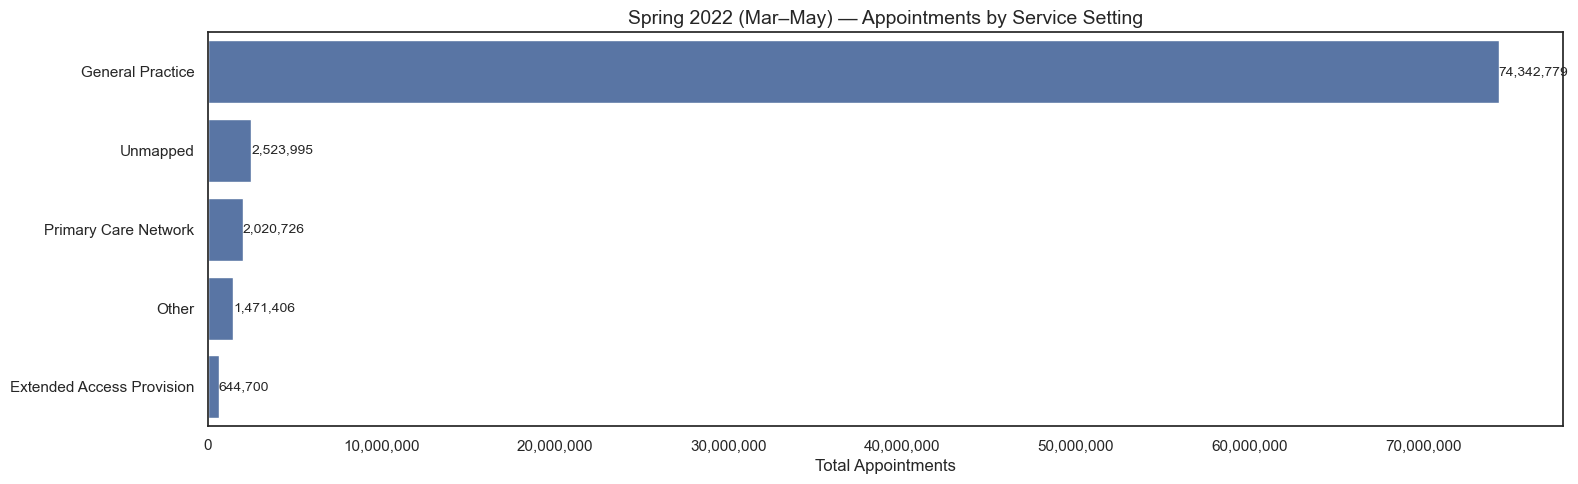

In [140]:
# Spring 2022 (Mar–May) — horizontal bar chart of total appointments by service setting.
fig, ax = plt.subplots(figsize=(16, 5))

sns.barplot(x='count_of_appointments', y='service_setting',
            data=nc_spring.sort_values('count_of_appointments', ascending=False),
            ax=ax, order=nc_spring.sort_values('count_of_appointments', ascending=False)['service_setting'])
ax.set_title('Spring 2022 (Mar–May) — Appointments by Service Setting', fontsize=14)
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.set_xlabel('Total Appointments')
ax.set_ylabel('')

for p in ax.patches:
    ax.annotate(f'{p.get_width():,.0f}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 

# Assignment activity 5

### Analyse tweets from Twitter with hashtags related to healthcare in the UK.

In [161]:
# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200


In [142]:
# Load the data set.
tweets.head()

# View the DataFrame.


,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",5,0,False,False,en
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en


In [144]:
tweets.columns.tolist()


['tweet_id',
 'tweet_full_text',
 'tweet_entities',
 'tweet_entities_hashtags',
 'tweet_metadata',
 'tweet_retweet_count',
 'tweet_favorite_count',
 'tweet_favorited',
 'tweet_retweeted',
 'tweet_lang']

In [145]:
# Would it be useful to only look at retweeted and favourite tweet messages?
# Explain your answer.

# Yes, it would be useful but not sufficient to focus only on retweeted
# and favourited tweets. Here is why:
#
# ARGUMENTS FOR filtering to retweeted/favourited tweets:
# - High engagement tweets (retweets and favourites) represent messages
#   that resonated with a wider audience and reflect broader public
#   sentiment rather than isolated opinions.
# - They are more likely to contain meaningful healthcare discussion
#   topics rather than spam or low quality posts.
# - Filtering reduces noise and focuses the analysis on tweets that
#   had measurable public impact.
#
# ARGUMENTS AGAINST relying solely on retweeted/favourited tweets:
# - The engagement metrics are heavily skewed. The median retweet count
#   is 1 and the median favourite count is 0, meaning most tweets have
#   very low engagement. Filtering too aggressively would remove the
#   majority of the dataset.
# - Original tweets with zero engagement may still contain relevant
#   healthcare hashtags and topics that are important for identifying
#   the full range of public discussion.
# - High retweet counts can be driven by celebrity accounts or viral
#   content that may not be representative of typical healthcare
#   sentiment.
#
# RECOMMENDATION:
# A combined approach would be most effective. Analyse the full dataset
# to identify the most common hashtags and topics, then use engagement
# metrics (retweet and favourite counts) as a weighting factor to
# highlight which topics are generating the most public attention.
# This preserves the breadth of the data while still leveraging
# engagement as a signal of importance.

# Demonstrate with data:
print('Engagement summary:')
print(tweets[['tweet_retweet_count', 'tweet_favorite_count']].describe())
print(f'\nTweets with at least 1 retweet: {(tweets["tweet_retweet_count"] > 0).sum()} / {len(tweets)}')
print(f'Tweets with at least 1 favourite: {(tweets["tweet_favorite_count"] > 0).sum()} / {len(tweets)}')



Engagement summary:
       tweet_retweet_count  tweet_favorite_count
count                1,174                 1,174
mean                     9                     0
std                     30                     2
min                      0                     0
25%                      0                     0
50%                      1                     0
75%                      3                     0
max                    303                    42

Tweets with at least 1 retweet: 648 / 1174
Tweets with at least 1 favourite: 147 / 1174


In [146]:
# Create a new DataFrame containing only the text.

# Subset, select only the text column
tweets_text = tweets[['tweet_full_text']].copy()

# View the DataFrame.
tweets_text


,tweet_full_text
0,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be..."
1,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…
2,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…
3,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…
4,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di..."
...,...
1169,RT @PotomacPhotonic: Potomac #Innovation Report: #precisionFabrication techniques Optimize #Microfluidic Mixing of Viscous Fluids \n\n#manuf…
1170,"Not a cent towards workers who would like to advance their training, especially those already employed by SHA or who for various reasons cannot obtain a student loan. Half of our department applie..."
1171,"The @hfmaorg Region 9 presents ""The Value of ESG to the Healthcare Industry"" and our own Kris Russell and Ron Present will be the key speakers. This #webinar will be taking place 9/13 and will exp..."
1172,Happy physiotherapy 🩺 day 🎉..\n#bpt #physiotherapy \n#HealthyNation #healthcare \n#medicalcare \n#csjmu .\n@WHO \n@MoHFW_INDIA \n@nitish_0210 https://t.co/NQHdIoYymC


In [164]:
# Loop through the messages, and create a list of values containing the # symbol.
hashtags = []

for text in tweets_text["tweet_full_text"]:
    tags = re.findall(r"#\w+", str(text))
    hashtags.extend(tags)

hashtag_series = pd.Series(hashtags)
hashtag_df = hashtag_series.value_counts().reset_index()
hashtag_df.columns = ["hashtag", "count"]

hashtag_df["count"] = hashtag_df["count"].astype(int)

hashtag_df.head()


,hashtag,count
0,#healthcare,599
1,#Healthcare,198
2,#health,70
3,#HealthCare,47
4,#AI,45


In [148]:
# Display the first 30 records.
hashtags[:30]


['As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-being of our community as our next https://t.co/yw0cstfmSI #Healthcare',
 "RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed.  We're #hiring for…",
 'RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…',
 'RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…',
 'ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #digitaltransformation #cybersecurity #accounting #finance #healthcare https://t.co/HC4tTrk8sW',
 'N

In [149]:
# Convert the series to a DataFrame in preparation for visualisation.
hashtag_series = pd.Series(hashtags)
hashtag_df = hashtag_series.to_frame(name="hashtag_tweets")

hashtag_df.head()

# Rename the columns.
hashtag_df = hashtag_df.value_counts().reset_index()
hashtag_df.columns = ["hashtag", "count"]
hashtag_df.head()


,hashtag,count
0,RT @imedverse: Lipid-Lowering Drugs\n\n#TipsForNewDocs #MedEd #MedTwitter #medicine #medical #medicare #health #healthcare #FOAMed #ClinicalP…,10
1,RT @CURE_Ecosystem: EXCLUSIVE footage. Just for our supporters. Who wants a first look at the Car? 👀 VROOM. NASCAR.. here we come!!\n\n#RACE4…,9
2,RT @pratititech: #AI tools in #healthcare!\n\nInfographic by @ingliguori\n\n#Python #Nodejs #MachineLearning #100daysofmlcode #HTML5 #RStats #S…,9
3,RT @philoasantemd: September is #WomenInMedicine Month! Thrilled to join @JulieSilverMD #SheLeadsHealthcare @ELAMProgram &amp; @AMWADoctors t…,8
4,RT @JeffWaltersSask: A good read on what nurses are going through as our HC system in #saskatchewan crumbles. Time for the @PremierScottMoe…,7


In [150]:
# Fix the count datatype.
hashtag_df["count"] = hashtag_df["count"].astype(int)

# View the result.
hashtag_df.dtypes


hashtag    object
count       int64
dtype: object

In [166]:
# Display records where the count is larger than 10.
print(hashtag_df["count"].describe())

hashtag_gt10 = hashtag_df[hashtag_df["count"] > 10]


count   1,681
mean        3
std        16
min         1
25%         1
50%         1
75%         2
max       599
Name: count, dtype: float64


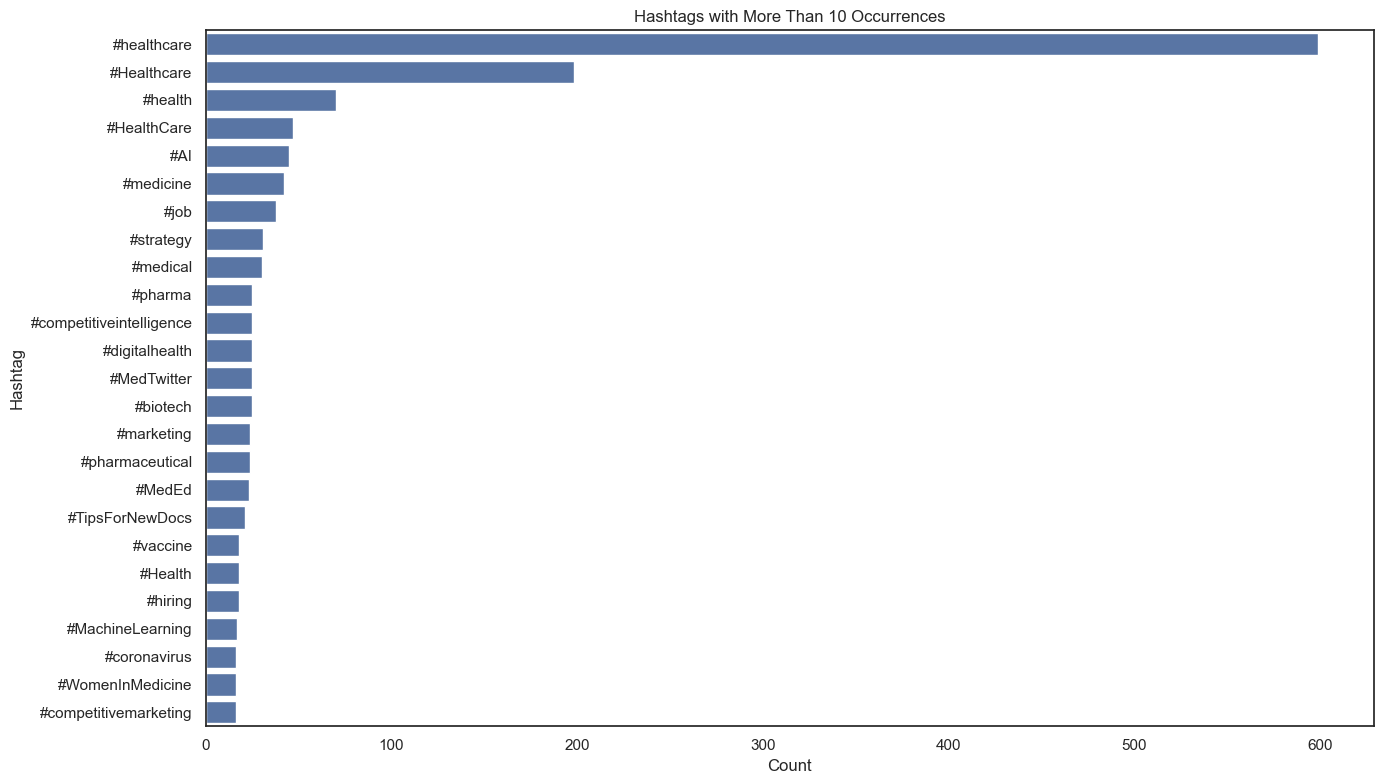

In [167]:
# Create a Seaborn barplot indicating records with a count >10 records.
hashtag_gt10 = hashtag_df[hashtag_df["count"] > 10].copy()
hashtag_gt10 = hashtag_gt10.sort_values("count", ascending=False).head(25)

plt.figure(figsize=(14, 8))
sns.barplot(x="count", y="hashtag", data=hashtag_gt10)
plt.title("Hashtags with More Than 10 Occurrences")
plt.xlabel("Count")
plt.ylabel("Hashtag")
plt.tight_layout()
plt.show()


# 

# Assignment activity 6

### Make recommendations to the NHS. 

In [168]:
# Prepare your workstation.
# Load the appointments_regional.csv file cleanly for Activity 6.
ar = pd.read_csv('appointments_regional.csv')

# View the DataFrame.
print('Shape:', ar.shape)
print('Columns:', ar.columns.tolist())
ar.head()

Shape: (596821, 7)
Columns: ['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type', 'appointment_mode', 'time_between_book_and_appointment', 'count_of_appointments']


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [169]:
# Print the min and max dates.
print('Earliest month:', ar['appointment_month'].min())
print('Latest month:', ar['appointment_month'].max())

Earliest month: 2020-01
Latest month: 2022-06


In [170]:
# Filter the data set to only look at data from 2021-08 onwards.
# This aligns ar with the nc dataset timeframe (Aug 2021 -- Jun 2022).
ar = ar[ar['appointment_month'] >= '2021-08']

print('Filtered shape:', ar.shape)
print('Date range:', ar['appointment_month'].min(), 'to', ar['appointment_month'].max())

Filtered shape: (223418, 7)
Date range: 2021-08 to 2022-06


**Question 1:** Should the NHS start looking at increasing staff levels? 

In [171]:
# Create an aggregated data set to review the different features.
# Q1: Is total monthly demand growing?
ar_monthly = (
    ar.groupby('appointment_month')['count_of_appointments']
    .sum()
    .reset_index()
)
ar_monthly.columns = ['appointment_month', 'total_appointments']

# View the DataFrame.
print(ar_monthly.to_string(index=False))

appointment_month  total_appointments
          2021-08            23852171
          2021-09            28522501
          2021-10            30303834
          2021-11            30405070
          2021-12            25140776
          2022-01            25635474
          2022-02            25355260
          2022-03            29595038
          2022-04            23913060
          2022-05            27495508
          2022-06            25828078


In [172]:
# Determine the total number of appointments per month.
# (Already computed in ar_monthly above.)

# Add a new column to indicate the average utilisation of services.
# Monthly aggregate / 30 to get to a daily value.
ar_monthly['daily_average'] = ar_monthly['total_appointments'] / 30

# View the DataFrame.
print(ar_monthly.to_string(index=False))

appointment_month  total_appointments  daily_average
          2021-08            23852171        795,072
          2021-09            28522501        950,750
          2021-10            30303834      1,010,128
          2021-11            30405070      1,013,502
          2021-12            25140776        838,026
          2022-01            25635474        854,516
          2022-02            25355260        845,175
          2022-03            29595038        986,501
          2022-04            23913060        797,102
          2022-05            27495508        916,517
          2022-06            25828078        860,936


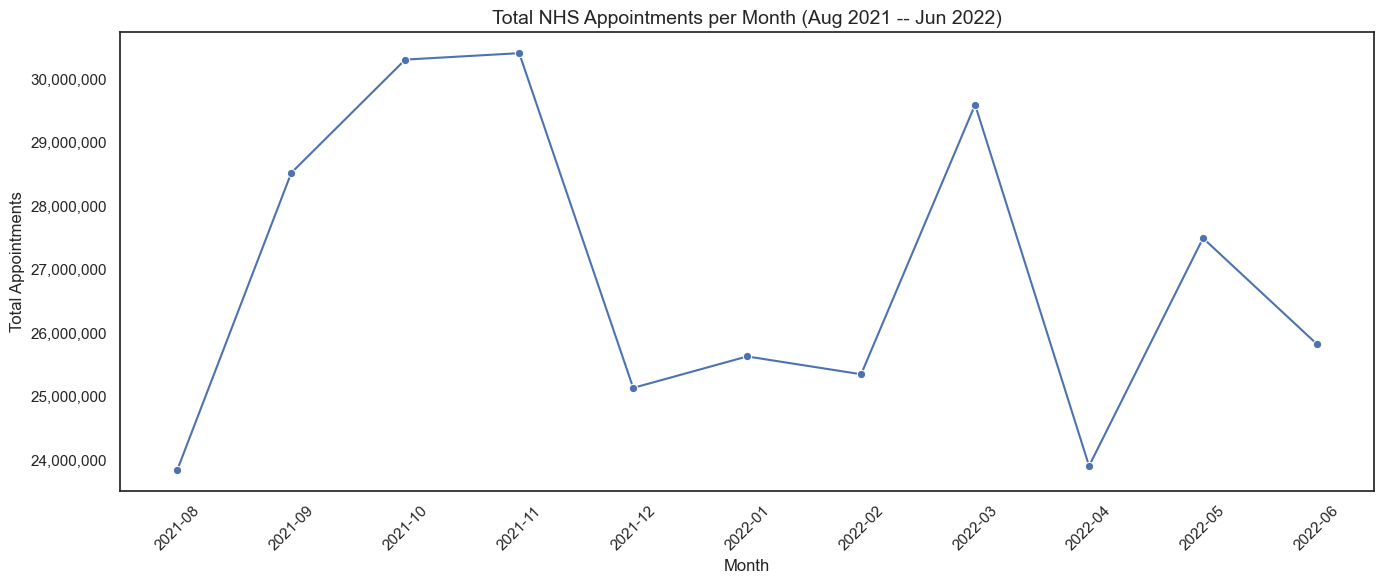

In [173]:
# Plot sum of count of monthly visits.
# Convert the appointment_month to string data type for ease of visualisation.
ar_monthly['appointment_month'] = ar_monthly['appointment_month'].astype(str)

# Create a lineplot with Seaborn.
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    x='appointment_month',
    y='total_appointments',
    data=ar_monthly,
    marker='o',
    ax=ax
)
ax.set_title('Total NHS Appointments per Month (Aug 2021 -- Jun 2022)', fontsize=14)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.set_xlabel('Month')
ax.set_ylabel('Total Appointments')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


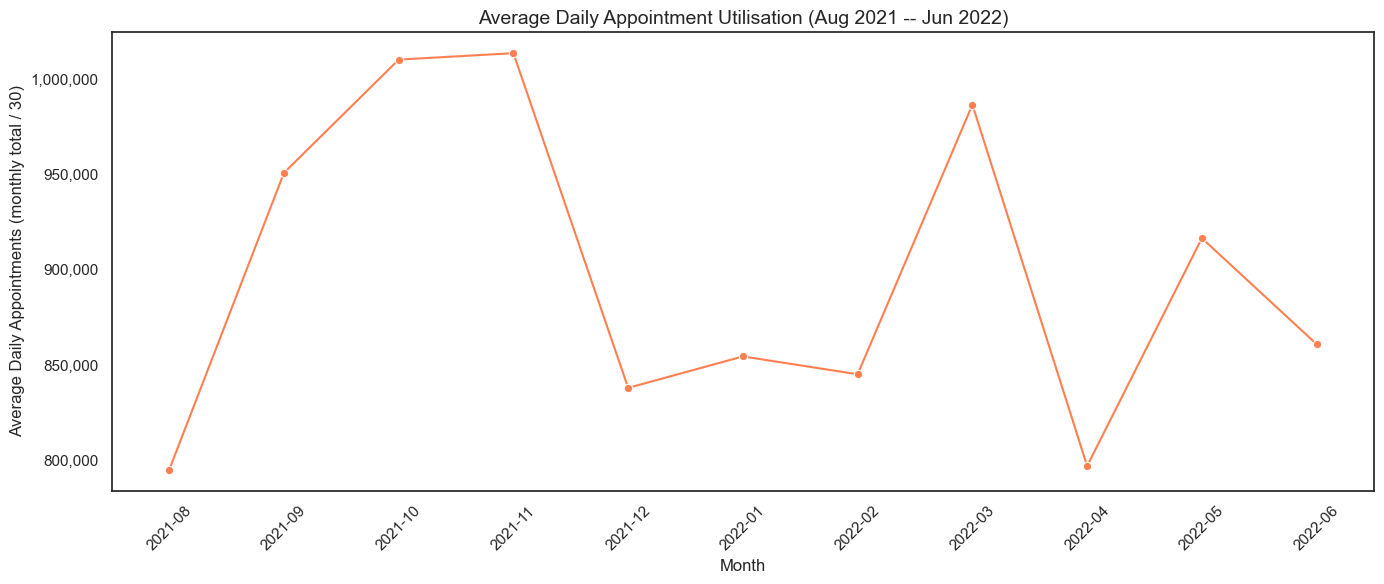

In [174]:
# Plot monthly capacity utilisation.
fig, ax = plt.subplots(figsize=(14, 6))

# Create a lineplot.
sns.lineplot(
    x='appointment_month',
    y='daily_average',
    data=ar_monthly,
    marker='o',
    color='coral',
    ax=ax
)
ax.set_title('Average Daily Appointment Utilisation (Aug 2021 -- Jun 2022)', fontsize=14)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.set_xlabel('Month')
ax.set_ylabel('Average Daily Appointments (monthly total / 30)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Question 2:** How do the healthcare professional types differ over time?

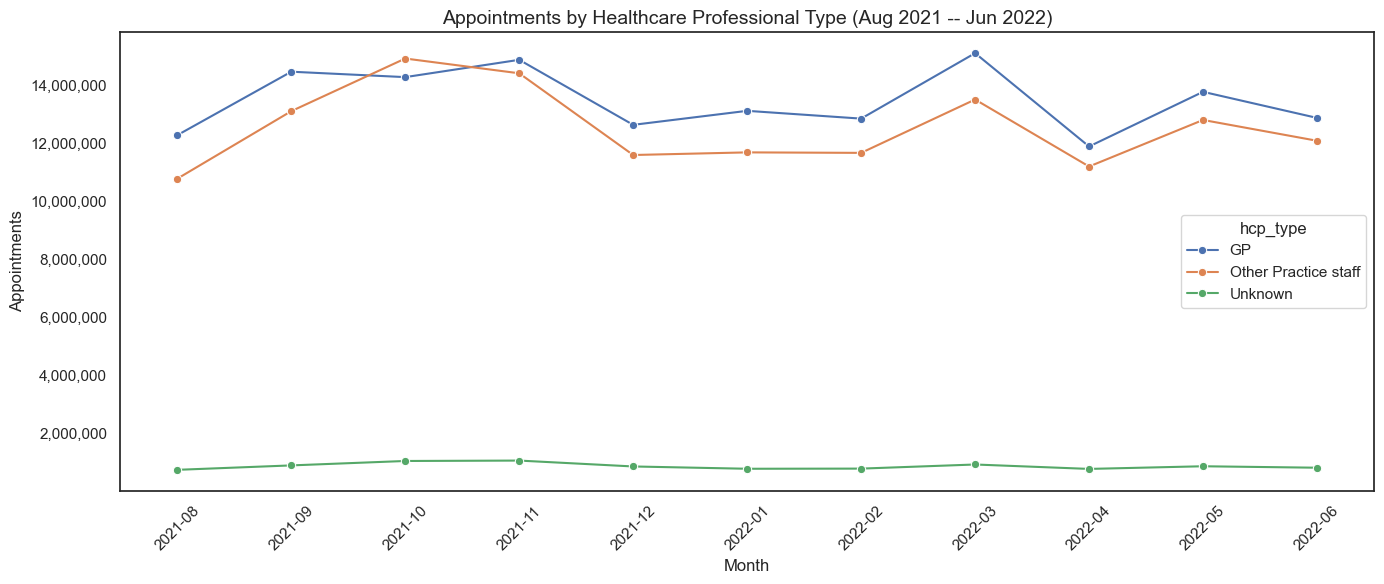

In [175]:
# Q2: How do the healthcare professional types differ over time?
# Group by month and HCP type to see if workload is shifting from GP to Other Practice Staff.
ar_hcp = (
    ar.groupby(['appointment_month', 'hcp_type'], as_index=False)['count_of_appointments']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    x='appointment_month',
    y='count_of_appointments',
    hue='hcp_type',
    data=ar_hcp,
    marker='o',
    ax=ax
)
ax.set_title('Appointments by Healthcare Professional Type (Aug 2021 -- Jun 2022)', fontsize=14)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.set_xlabel('Month')
ax.set_ylabel('Appointments')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Question 3:** Are there significant changes in whether or not visits are attended?

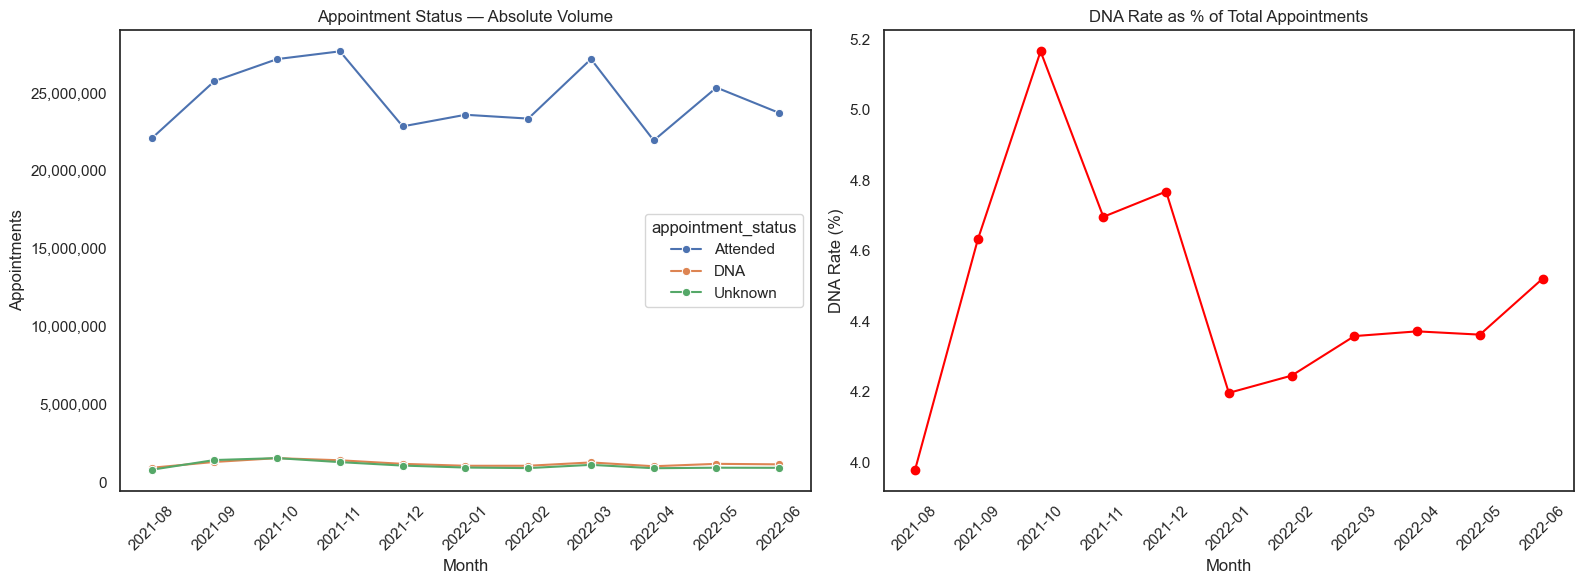

Average monthly DNA rate: 4.48%
Range: 3.98% to 5.17%
Total DNA appointments (Aug 2021 -- Jun 2022): 13,318,384


In [176]:
# Q3: Are there significant changes in whether or not visits are attended?
# This is the KEY analysis — DNA waste is the strongest "better use of resources" lever.
ar_status = (
    ar.groupby(['appointment_month', 'appointment_status'], as_index=False)['count_of_appointments']
    .sum()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: absolute volumes by status.
sns.lineplot(
    x='appointment_month',
    y='count_of_appointments',
    hue='appointment_status',
    data=ar_status,
    marker='o',
    ax=ax1
)
ax1.set_title('Appointment Status — Absolute Volume')
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax1.set_xlabel('Month')
ax1.set_ylabel('Appointments')
ax1.tick_params(axis='x', rotation=45)

# Right: DNA rate as percentage of total.
ar_pivot = ar_status.pivot(
    index='appointment_month',
    columns='appointment_status',
    values='count_of_appointments'
)
ar_pivot['DNA_rate'] = ar_pivot['DNA'] / ar_pivot.sum(axis=1) * 100

ax2.plot(ar_pivot.index, ar_pivot['DNA_rate'], marker='o', color='red')
ax2.set_title('DNA Rate as % of Total Appointments')
ax2.set_xlabel('Month')
ax2.set_ylabel('DNA Rate (%)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print the DNA rate summary.
print(f"Average monthly DNA rate: {ar_pivot['DNA_rate'].mean():.2f}%")
print(f"Range: {ar_pivot['DNA_rate'].min():.2f}% to {ar_pivot['DNA_rate'].max():.2f}%")
total_dna = ar_pivot['DNA'].sum()
print(f"Total DNA appointments (Aug 2021 -- Jun 2022): {total_dna:,.0f}")



**Question 4:** Are there changes in terms of appointment type and the busiest months?

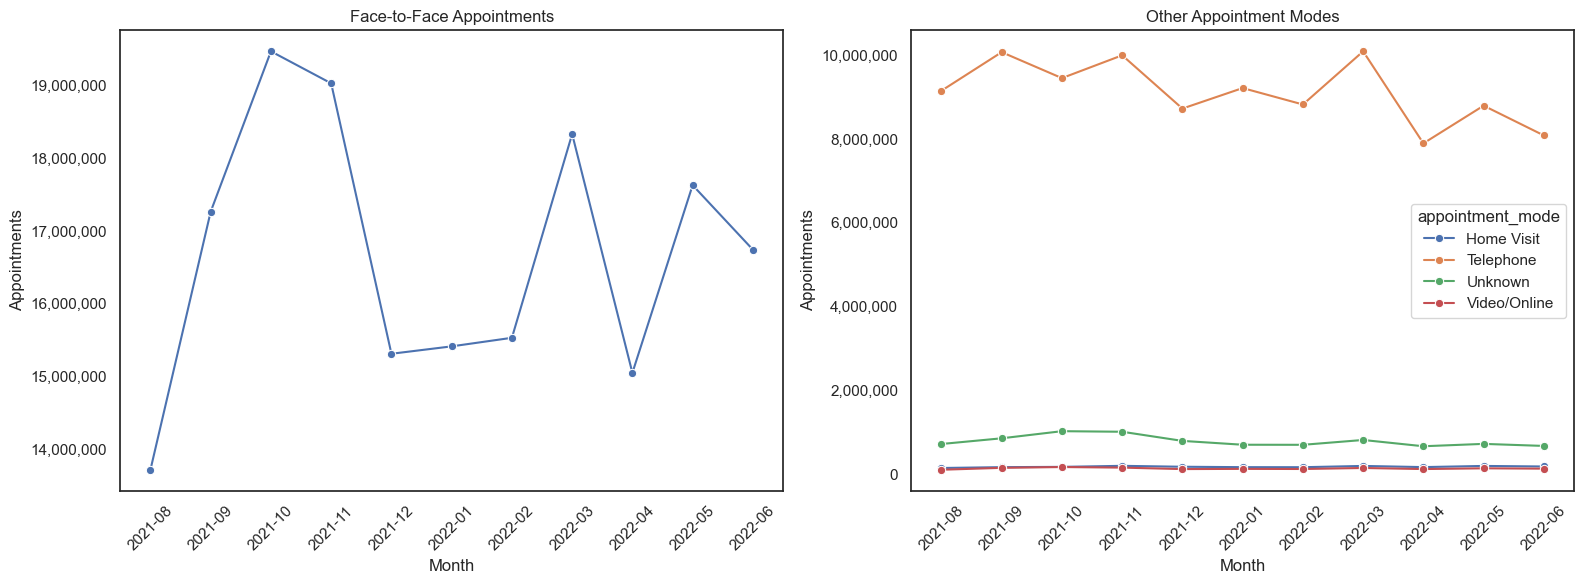

In [177]:
# Q4: Are there changes in terms of appointment type and the busiest months?
# Split Face-to-Face (dominant) vs other modes for legibility.
ar_mode = (
    ar.groupby(['appointment_month', 'appointment_mode'], as_index=False)['count_of_appointments']
    .sum()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Left: Face-to-Face (dominant mode).
mode_f2f = ar_mode[ar_mode['appointment_mode'] == 'Face-to-Face']
sns.lineplot(x='appointment_month', y='count_of_appointments',
             data=mode_f2f, marker='o', ax=ax1)
ax1.set_title('Face-to-Face Appointments')
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax1.set_xlabel('Month')
ax1.set_ylabel('Appointments')
ax1.tick_params(axis='x', rotation=45)

# Right: all other modes.
mode_other = ar_mode[ar_mode['appointment_mode'] != 'Face-to-Face']
sns.lineplot(x='appointment_month', y='count_of_appointments',
             hue='appointment_mode', data=mode_other, marker='o', ax=ax2)
ax2.set_title('Other Appointment Modes')
ax2.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax2.set_xlabel('Month')
ax2.set_ylabel('Appointments')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Question 5:** Are there any trends in time between booking and appointment?

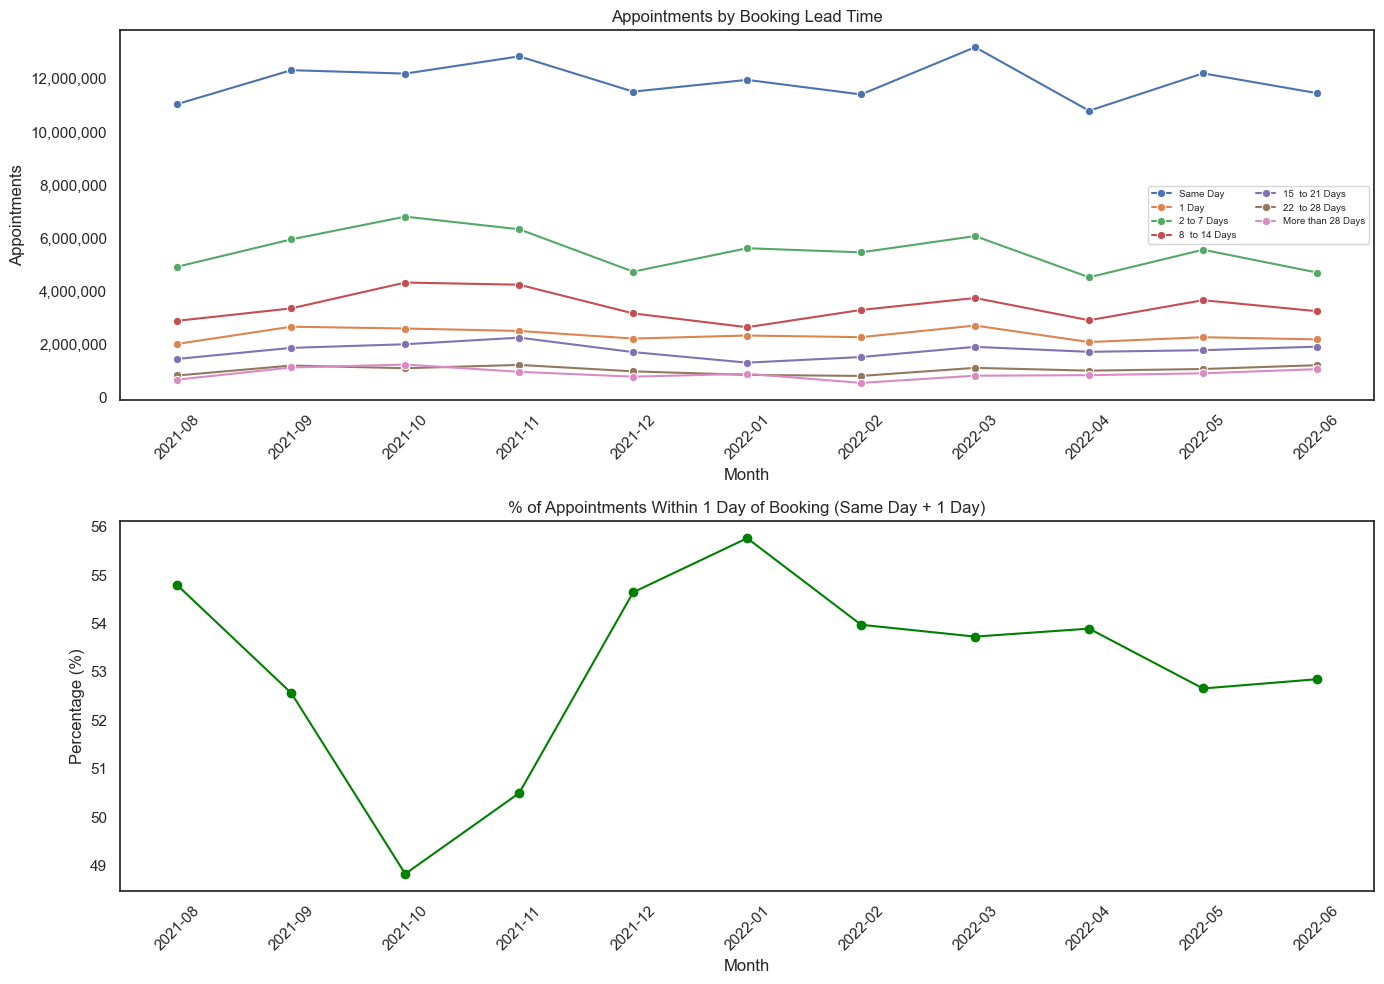

In [178]:
# Q5: Are there any trends in time between booking and appointment?
# Longer lead times = demand outstripping supply.
ar_lead = (
    ar.groupby(['appointment_month', 'time_between_book_and_appointment'],
               as_index=False)['count_of_appointments']
    .sum()
)

# Compute the proportion of "Same Day + 1 Day" as a quick-access metric.
ar_lead_pivot = ar_lead.pivot(
    index='appointment_month',
    columns='time_between_book_and_appointment',
    values='count_of_appointments'
).fillna(0)
ar_lead_pivot['total'] = ar_lead_pivot.sum(axis=1)
ar_lead_pivot['pct_within_1_day'] = (
    (ar_lead_pivot.get('Same Day', 0) + ar_lead_pivot.get('1 Day', 0))
    / ar_lead_pivot['total'] * 100
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Top: all lead time categories.
lead_order = ['Same Day', '1 Day', '2 to 7 Days', '8  to 14 Days',
              '15  to 21 Days', '22  to 28 Days', 'More than 28 Days']
ar_lead_filtered = ar_lead[ar_lead['time_between_book_and_appointment'].isin(lead_order)]
sns.lineplot(x='appointment_month', y='count_of_appointments',
             hue='time_between_book_and_appointment', hue_order=lead_order,
             data=ar_lead_filtered, marker='o', ax=ax1)
ax1.set_title('Appointments by Booking Lead Time')
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax1.set_xlabel('Month')
ax1.set_ylabel('Appointments')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=7, ncol=2)

# Bottom: % of appointments seen within 1 day of booking.
ax2.plot(ar_lead_pivot.index, ar_lead_pivot['pct_within_1_day'],
         marker='o', color='green')
ax2.set_title('% of Appointments Within 1 Day of Booking (Same Day + 1 Day)')
ax2.set_xlabel('Month')
ax2.set_ylabel('Percentage (%)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Question 6:** How do the various service settings compare?

In [179]:
# Q6: How do the various service settings compare?
# Recreate nc_ss from nc for safety in case of kernel restart.
nc_ss = (
    nc.groupby(['appointment_month', 'service_setting'], as_index=False)['count_of_appointments']
    .sum()
)
nc_ss.head()


,appointment_month,service_setting,count_of_appointments
0,2021-08,Extended Access Provision,160927
1,2021-08,General Practice,21575852
2,2021-08,Other,449101
3,2021-08,Primary Care Network,432448
4,2021-08,Unmapped,1233843


In [180]:
# Create a new DataFrame consisting of the month of appointment and the number of appointments.
nc_monthly_ss = (
    nc.groupby(['appointment_month', 'service_setting'], as_index=False)['count_of_appointments']
    .sum()
)

# View the DataFrame.
nc_monthly_ss.head(10)


,appointment_month,service_setting,count_of_appointments
0,2021-08,Extended Access Provision,160927
1,2021-08,General Practice,21575852
2,2021-08,Other,449101
3,2021-08,Primary Care Network,432448
4,2021-08,Unmapped,1233843
5,2021-09,Extended Access Provision,187906
6,2021-09,General Practice,25940821
7,2021-09,Other,527174
8,2021-09,Primary Care Network,530485
9,2021-09,Unmapped,1336115


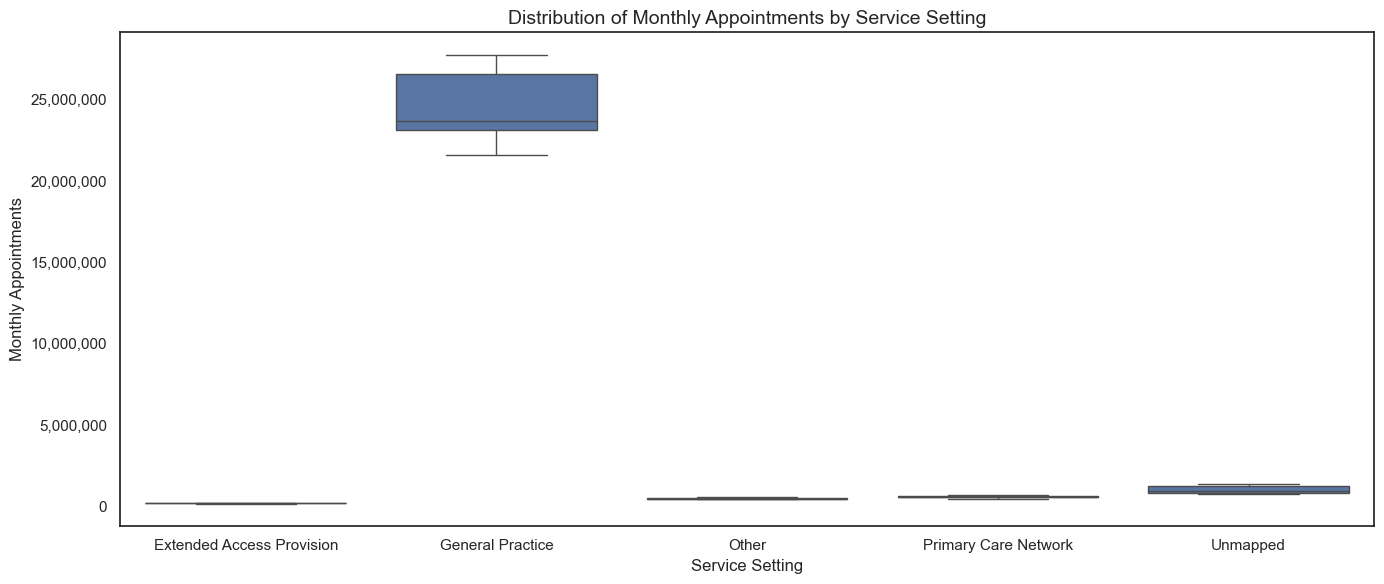

In [181]:
# Create a boxplot in Seaborn based on the new DataFrame to indicate
# the service settings for the number of appointments.
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    x='service_setting',
    y='count_of_appointments',
    data=nc_monthly_ss,
    ax=ax
)
ax.set_title('Distribution of Monthly Appointments by Service Setting', fontsize=14)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.set_xlabel('Service Setting')
ax.set_ylabel('Monthly Appointments')
plt.tight_layout()
plt.show()


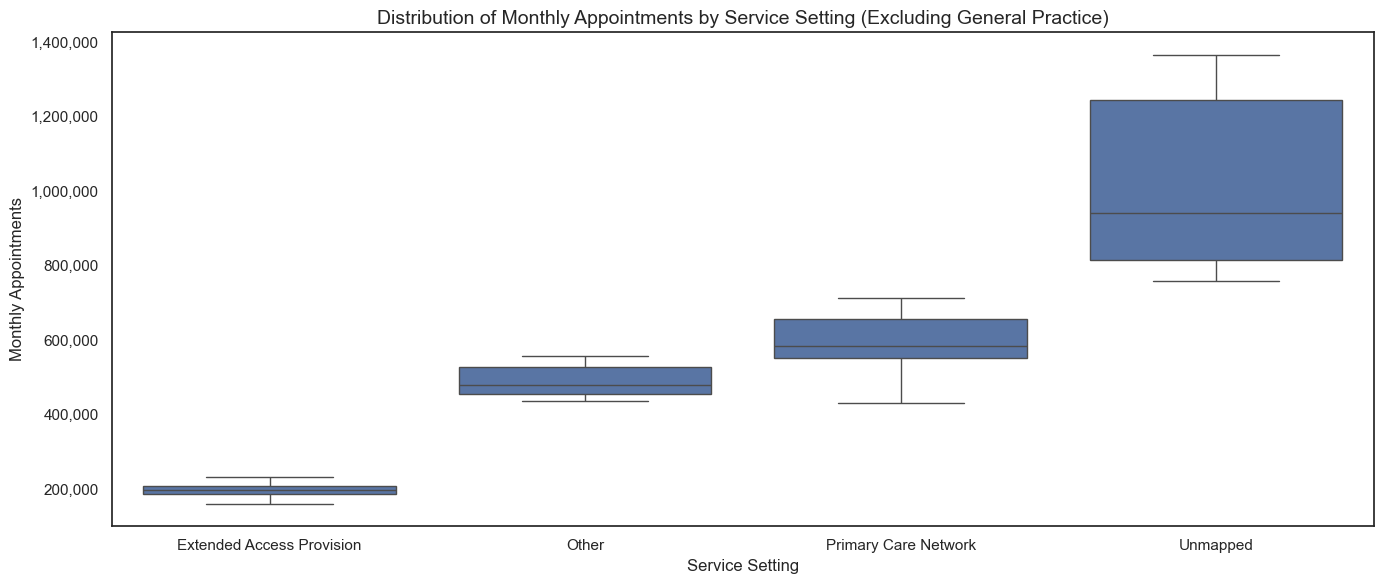

In [182]:
# Create a boxplot in Seaborn where you concentrate on all
# the service settings, excluding GP visits.
# This reveals whether PCN, Extended Access, and Other settings
# carry meaningful volume or are underutilised.
nc_non_gp = nc_monthly_ss[nc_monthly_ss['service_setting'] != 'General Practice']

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    x='service_setting',
    y='count_of_appointments',
    data=nc_non_gp,
    ax=ax
)
ax.set_title('Distribution of Monthly Appointments by Service Setting (Excluding General Practice)',
             fontsize=14)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.set_xlabel('Service Setting')
ax.set_ylabel('Monthly Appointments')
plt.tight_layout()
plt.show()


## External Evidence Supporting Capacity Assessment

In [183]:
# Purpose:
# The NHS appointment datasets analysed in Activities 1–6 provide insight
# into demand trends and consultation duration patterns across ICBs.
# However, while the internal data shows changes in utilisation over time,
# it does not explain the broader structural drivers behind those changes.

# To strengthen the assessment of whether current utilisation justifies
# expanding capacity, this section incorporates external evidence obtained
# through web scraping. The objective is to contextualise observed demand
# trends using publicly available data on relevant external factors
# such as population change, workforce availability, or public health
# conditions.

# Rationale:
# Internal appointment data alone cannot determine whether rising volumes
# reflect structural growth in underlying need, workforce constraints,
# policy shifts, or post-pandemic behavioural effects. External data
# provides supply-side and demographic context necessary for a more
# evidence-based capacity recommendation.

# Approach:
# 1. Identify a credible public source relevant to primary care demand
#    or workforce capacity.
# 2. Scrape structured data using requests and BeautifulSoup.
# 3. Clean and transform the extracted information into a pandas DataFrame.
# 4. Compare or align the external metric with internal appointment data
#    at a compatible time or regional level.
# 5. Evaluate whether external trends support the case for capacity
#    expansion or suggest improved resource allocation within
#    existing capacity.

# This section extends the analysis beyond descriptive internal metrics
# and introduces external validation to support strategic conclusions.


In [184]:
# Helper functions
def get_gp_workforce_publication_links(series_url: str) -> list[str]:
    """
    Scrape the NHS Digital series page and return ALL publication page links
    that follow the expected URL format containing a date slug, e.g.
    .../general-and-personal-medical-services/31-july-2022
    """
    html = requests.get(series_url, timeout=30).text
    soup = BeautifulSoup(html, "html.parser")

    links = []
    for a in soup.select('a[href]'):
        href = a.get("href", "").strip()

        # Convert relative links to absolute
        if href.startswith("/"):
            href = "https://digital.nhs.uk" + href

        # Keep only publication pages in this series that have a date slug
        # This avoids picking up navigation links and “supplementary information” links.
        if re.search(r"/publications/statistical/general-and-personal-medical-services/\d{1,2}-[a-z]+-\d{4}(/|$)", href):
            links.append(href)

    # Deduplicate while preserving order
    links = list(dict.fromkeys(links))
    return links

def extract_publication_date_from_url(url: str) -> date | None:
    """
    Extract a date from the end of the publication URL:
    .../31-july-2022  -> date(2022, 7, 31)
    Returns None if the URL does not match the expected pattern.
    """
    m = re.search(r"/(\d{1,2}-[a-z]+-\d{4})(?:/|$)", url)
    if not m:
        return None

    slug = m.group(1)  # e.g. "31-july-2022"
    try:
        return datetime.strptime(slug, "%d-%B-%Y").date()
    except ValueError:
        # Month names should parse (july, february, etc). If it fails, skip safely.
        return None

def filter_links_by_date(links: list[str], start: date, end: date) -> list[str]:
    """
    Filter publication URLs to those whose publication date (from the URL slug)
    lies within [start, end].
    """
    kept = []
    for u in links:
        d = extract_publication_date_from_url(u)
        if d is None:
            continue
        if start <= d <= end:
            kept.append((d, u))

    # Sort chronologically (so your output matches the internal dataset timeline)
    kept.sort(key=lambda x: x[0])
    return [u for d, u in kept]
    

In [185]:
# The series page that contains the publication lists in HTML
series_url = "https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services"

# Appointments dataset: Aug 2021 → Jun 2022
start = date(2021, 8, 1)
end   = date(2022, 6, 30)

all_pub_links = get_gp_workforce_publication_links(series_url)
pub_links = filter_links_by_date(all_pub_links, start, end)

print("Total publication links found on series page:", len(all_pub_links))
print("Links in assignment window (Aug 2021–Jun 2022):", len(pub_links))

# Print the filtered links (this is the list you wanted, now correctly filtered)
for u in pub_links:
    print(u)


Total publication links found on series page: 54
Links in assignment window (Aug 2021–Jun 2022): 7
https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/31-december-2021
https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/31-january-2022
https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/28-february-2022
https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/31-march-2022
https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/30-april-2022
https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/31-may-2022
https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/30-june-2022


In [186]:
# From each publication page, extract the "Bulletin tables" (Excel) download link

import pandas as pd
import requests
from bs4 import BeautifulSoup

def get_bulletin_xlsx_link(publication_url: str) -> str | None:
    """
    Each publication page has a Resources section that includes a link like:
    'Bulletin Tables - <Month Year>' (XLSX).
    This function returns the first matching XLSX link.
    """
    html = requests.get(publication_url, timeout=30).text
    soup = BeautifulSoup(html, "html.parser")

    # Look for any anchor that points to an .xlsx and has "Bulletin" in its text
    for a in soup.select('a[href]'):
        text = (a.get_text(" ", strip=True) or "").lower()
        href = a.get("href", "").strip()

        if "bulletin" in text and href.lower().endswith(".xlsx"):
            if href.startswith("/"):
                href = "https://digital.nhs.uk" + href
            return href

    return None

bulletin_links = []
for pub_url in pub_links:
    xlsx_url = get_bulletin_xlsx_link(pub_url)
    bulletin_links.append({"publication_url": pub_url, "bulletin_xlsx_url": xlsx_url})

bulletin_df = pd.DataFrame(bulletin_links)
bulletin_df


,publication_url,bulletin_xlsx_url
0,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/31-december-2021,https://files.digital.nhs.uk/8A/92F1E1/GPW%20Bulletin%20Tables%20-%20December%202021.xlsx
1,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/31-january-2022,https://files.digital.nhs.uk/62/DA31DF/GPW%20Bulletin%20Tables%20-%20January%202022.xlsx
2,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/28-february-2022,https://files.digital.nhs.uk/76/67C66A/GPW%20Bulletin%20Tables%20-%20February%202022.xlsx
3,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/31-march-2022,https://files.digital.nhs.uk/B0/955BC6/GPW%20Bulletin%20Tables%20-%20March%202022.xlsx
4,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/30-april-2022,https://files.digital.nhs.uk/BD/7B818D/GPW%20Bulletin%20Tables%20-%20April%202022.xlsx
5,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/31-may-2022,https://files.digital.nhs.uk/2F/1B0683/GPW%20Bulletin%20Tables%20-%20May%202022.xlsx
6,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/30-june-2022,https://files.digital.nhs.uk/78/D15594/GPW%20Bulletin%20Tables%20-%20June%202022.xlsx


In [187]:
def extract_date_from_url(url):
    m = re.search(r"/(\d{1,2}-[a-z]+-\d{4})", url)
    if not m:
        return None
    return datetime.strptime(m.group(1), "%d-%B-%Y").date()

bulletin_df["publication_date"] = bulletin_df["publication_url"].apply(extract_date_from_url)

# Sort chronologically (important before merging later)
bulletin_df = bulletin_df.sort_values("publication_date").reset_index(drop=True)

bulletin_df


,publication_url,bulletin_xlsx_url,publication_date
0,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/31-december-2021,https://files.digital.nhs.uk/8A/92F1E1/GPW%20Bulletin%20Tables%20-%20December%202021.xlsx,2021-12-31
1,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/31-january-2022,https://files.digital.nhs.uk/62/DA31DF/GPW%20Bulletin%20Tables%20-%20January%202022.xlsx,2022-01-31
2,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/28-february-2022,https://files.digital.nhs.uk/76/67C66A/GPW%20Bulletin%20Tables%20-%20February%202022.xlsx,2022-02-28
3,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/31-march-2022,https://files.digital.nhs.uk/B0/955BC6/GPW%20Bulletin%20Tables%20-%20March%202022.xlsx,2022-03-31
4,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/30-april-2022,https://files.digital.nhs.uk/BD/7B818D/GPW%20Bulletin%20Tables%20-%20April%202022.xlsx,2022-04-30
5,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/31-may-2022,https://files.digital.nhs.uk/2F/1B0683/GPW%20Bulletin%20Tables%20-%20May%202022.xlsx,2022-05-31
6,https://digital.nhs.uk/data-and-information/publications/statistical/general-and-personal-medical-services/30-june-2022,https://files.digital.nhs.uk/78/D15594/GPW%20Bulletin%20Tables%20-%20June%202022.xlsx,2022-06-30


In [188]:
def extract_england_fte_from_excel(xlsx_url):
    r = requests.get(xlsx_url)
    file = io.BytesIO(r.content)

    # Read all sheets to inspect structure once
    xls = pd.ExcelFile(file)

    # Usually workforce totals are in first sheet
    df = pd.read_excel(xls, sheet_name=0)

    # You may need to adjust column names depending on sheet layout
    # For now we just return the dataframe so you can inspect structure
    return df

# Test on ONE month first
test_df = extract_england_fte_from_excel(bulletin_df.loc[0, "bulletin_xlsx_url"])
test_df.head()


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,"General Practice Workforce, England",NaN,NaN,NaN,NaN,NaN
1,"Bulletin Tables, September 2015 - December 2021",NaN,NaN,NaN,NaN,NaN
2,Official Statistics,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,Publication Date:,NaN,2022-02-10 00:00:00,NaN,NaN,NaN


In [189]:
# Inspect sheet names 
xlsx_url = bulletin_df.loc[0, "bulletin_xlsx_url"]
r = requests.get(xlsx_url)
file = io.BytesIO(r.content)

xls = pd.ExcelFile(file)
xls.sheet_names


['Title and Contents',
 '1a',
 '1b',
 '2a',
 '2b',
 '3',
 '4',
 '5',
 '6a',
 '6b',
 '7',
 'Annex A',
 'Annex B',
 'Annex C']

In [190]:
# Quick peek at a few sheets to find the one with England totals
for name in xls.sheet_names[:8]:
    df = pd.read_excel(xls, sheet_name=name, nrows=12, header=None)
    print("\n---", name, "---")
    display(df)
    


--- Title and Contents ---


,0,1,2
0,NaN,NaN,NaN
1,"General Practice Workforce, England",NaN,NaN
2,"Bulletin Tables, September 2015 - December 2021",NaN,NaN
3,Official Statistics,NaN,NaN
4,NaN,NaN,NaN
5,Publication Date:,NaN,2022-02-10 00:00:00
6,Link to publication:,NaN,https://digital.nhs.uk/pubs/gpworkdec21
7,NaN,NaN,NaN
8,Introduction,NaN,NaN
9,This document contains workforce figures for traditional 'high street' General (Medical) Practices and the patients they support.,NaN,NaN



--- 1a ---


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Table 1a: General Medical Practice staff: full-time equivalent (FTE) by gender and role, September 2015 - December 2021",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Official Statistics 1,2,3,18",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Data includes estimates for practices that did not provide fully valid staff records. The percentage of FTE that is estimated is presented for each staff group, and includes full19 and partial20 e...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"For December 2016 and June 2017, when quarterly extracts were first introduced, data is only available for GPs and not for the other three staff groups.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,"User note: Groups can be expanded or shrunk one at a time by clicking on the [+] plus or [-] boxes beside the relevant row, or all together using the [1] and [2] boxes in the top-left of the file.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,England,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Full-time equivalent (FTE) and Percentages



--- 1b ---


...

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Table 3: Full-time equivalent work commitment: General Medical Practice staff: headcount by role and work commitment September 2015 - December 2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Official Statistics 1,2,3,4",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Data does not include estimates for practices that did not provide fully valid staff records. Details on the percentage of practices requiring full or partial estimation can be found in Annex A.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"For December 2016 and June 2017, when quarterly extracts were first introduced, data is only available for GPs and not for the other three staff groups.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Male and Female figures will not sum to Totals due to a number of GPs with unknown gender.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,"User note: Groups can be expanded or shrunk one at a time by clicking on the [+] plus or [-] boxes beside the relevant row, or all together using the [1] and [2] boxes in the top-left of the file.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- 4 ---


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Table 4: General Medical Practitioners: headcount by role and Country of Primary Medical Qualification, September 2015 - December 2021",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Official Statistics 1,2,3,10",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Data includes estimates for practices that did not provide fully valid staff records. Headcount estimates are produced from full11 estimations only. Details on the percentage of practices requirin...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,England,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Headcount and Percentages
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,"September\n2015 4,5",March\n2016 5,September\n2016,December\n2016,March\n2017 6,June\n2017,September\n2017,December\n2017,March\n2018,...,December\n2020,March\n2021,June 2021,July 2021,August 2021,September 2021,October 2021,November 2021,December 2021,% difference December 2020 - December 2021
9,All Qualified Permanent GPs (excludes GPs in Training Grade & Locums),34828,34687,34662,34512,34307,34136,34271,34424,34446,...,35330,35579,35505,35336,35439,35625,35589,35629,35624,1



--- 5 ---


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Table 5: Selected General Medical Practice and Patient statistics: counts and full-time equivalent (FTE), September 2015 - December 2021",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Official Statistics 1,2,3,9",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Data includes estimates for practices that did not provide fully valid staff records. FTE estimates include full10 and partial11 estimates. Details on the percentage of practices requiring full or...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"For December 2016 and June 2017, when quarterly extracts were first introduced, data is only available for GPs and not for the other three staff groups.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,England,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Counts, full-time equivalent (FTE) and percentages"
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,September\n2015 5,March\n2016 5,September\n2016,December\n2016 6,March\n2017 7,June\n2017 6,September\n2017,December\n2017,March\n2018,...,December\n2020,March\n2021,June 2021,July 2021,August 2021,September 2021,October 2021,November 2021,December 2021,% difference December 2020 - December 2021


In [191]:
# We anchor external evidence to the SAME time window as the provided
# internal appointments dataset (Aug 2021 -> Jun 2022).

# use the June 2022 "Bulletin Tables" XLSX because it is cumulative:
# it contains the historical series up to June 2022, so one download is
# enough, and we can filter to Aug 2021 -> Jun 2022 inside the file.

START = date(2021, 8, 1)
END   = date(2022, 6, 30)

# Your existing dataframe with the scraped links:
# bulletin_df columns: ["publication_url", "bulletin_xlsx_url", ...]
# Add a proper publication date column (parsed from the URL)
def extract_pub_date_from_url(u: str):
    m = re.search(r"/(\d{1,2})-([a-z]+)-(\d{4})$", u)
    if not m:
        return None
    day, mon, yr = m.group(1), m.group(2), m.group(3)
    return pd.to_datetime(f"{day} {mon} {yr}", dayfirst=True, errors="coerce")

bulletin_df = bulletin_df.copy()
bulletin_df["pub_date"] = bulletin_df["publication_url"].apply(extract_pub_date_from_url)

# Choose the END month publication (June 2022)
june_row = bulletin_df.loc[bulletin_df["pub_date"] == pd.Timestamp("2022-06-30")].head(1)
if june_row.empty:
    raise ValueError("Could not find the 30-june-2022 publication in bulletin_df.")

june_xlsx_url = june_row["bulletin_xlsx_url"].iloc[0]
print("Using June 2022 bulletin XLSX:", june_xlsx_url)

# Download into memory
resp = requests.get(june_xlsx_url, timeout=60)
resp.raise_for_status()
xlsx_file = io.BytesIO(resp.content)

# Inspect sheets (this is useful, not useless)
xls = pd.ExcelFile(xlsx_file)
xls.sheet_names

# this will return an excel workbook containing external data such as GP FTE


Using June 2022 bulletin XLSX: https://files.digital.nhs.uk/78/D15594/GPW%20Bulletin%20Tables%20-%20June%202022.xlsx


['Title and Contents',
 '1a',
 '1b',
 '2a',
 '2b',
 '3',
 '4',
 '5',
 '6a',
 '6b',
 '7',
 'Annex A',
 'Annex B',
 'Annex C']

In [192]:
# Clean sheet 1a
df_1a = pd.read_excel(xls, sheet_name="1a", skiprows=11)

# First column is the metric name
df_1a = df_1a.rename(columns={df_1a.columns[0]: "metric"})

# Drop completely empty rows
df_1a = df_1a[df_1a["metric"].notna()]

# Keep only the row for total GP FTE
gp_row = df_1a[df_1a["metric"].str.contains(r"\bAll GPs\b", case=False, na=False)].copy()

gp_row


,metric,"September\n2015 4,5,6",March\n2016 5,September\n2016 7,December\n2016 8,"March\n2017 9,10",June\n2017 8,September\n2017,December\n2017,March\n2018 11,...,October 2021,November 2021,December 2021,January 2022,February 2022,March 2022,April 2022,May 2022,June 2022,% difference June 2021 - June 2022
4,"All GPs 10,11,13","34,392","34,744","35,206","34,946","34,464","34,109","34,637","34,287","34,105",...,"36,316","36,206","36,191","36,009","36,141","35,988","35,855","35,626","35,449",1


In [193]:
gp_row.columns


Index(['metric', 'September\n2015 4,5,6', 'March\n2016 5', 'September\n2016 7',
       'December\n2016 8', 'March\n2017 9,10', 'June\n2017 8',
       'September\n2017', 'December\n2017 ', 'March\n2018 11', 'June\n2018 12',
       'September\n2018', 'December\n2018', 'March\n2019', 'June\n2019 14',
       'September\n2019', 'December\n2019', 'March\n2020', 'June\n2020',
       'September\n2020', 'December\n2020', 'March\n2021', 'June \n2021',
       'July \n2021', 'August 2021', 'September 2021', 'October 2021',
       'November 2021', 'December 2021', 'January 2022', 'February 2022',
       'March 2022', 'April 2022', 'May 2022', 'June 2022',
       '% difference June 2021 - June 2022'],
      dtype='object')

In [194]:
# Wide -> long
gp_long = gp_row.melt(id_vars="metric", var_name="month", value_name="fte")

# Convert month column to datetime
gp_long["month"] = pd.to_datetime(gp_long["month"], errors="coerce")

# Keep only assignment window
mask = (gp_long["month"].dt.date >= START) & (gp_long["month"].dt.date <= END)
gp_fte_aug21_jun22 = gp_long.loc[mask].sort_values("month").reset_index(drop=True)

gp_fte_aug21_jun22


,metric,month,fte
0,"All GPs 10,11,13",2021-08-01,"36,461"
1,"All GPs 10,11,13",2021-09-01,"36,495"
2,"All GPs 10,11,13",2021-10-01,"36,316"
3,"All GPs 10,11,13",2021-11-01,"36,206"
4,"All GPs 10,11,13",2021-12-01,"36,191"
5,"All GPs 10,11,13",2022-01-01,"36,009"
6,"All GPs 10,11,13",2022-02-01,"36,141"
7,"All GPs 10,11,13",2022-03-01,"35,988"
8,"All GPs 10,11,13",2022-04-01,"35,855"
9,"All GPs 10,11,13",2022-05-01,"35,626"


In [195]:
# Extract external GP workforce capacity series (Sheet 1a)

# Why sheet "1a"?
# In the NHS General Practice Workforce bulletin:
#   • Sheet 1a contains England-level FULL-TIME EQUIVALENT (FTE) totals.
#   • FTE is a workload-adjusted measure (1.0 = full-time 37.5 hours/week).
#
# We choose FTE rather than headcount because:
#   • It reflects effective capacity, not just number of individuals.
#   • It aligns directly with modelling workload pressure.

#
# Objective:
#   Construct a clean monthly time series of:
#       Total GP FTE (England)
#   to later compute:
#       Appointments per GP FTE
#   as a workload intensity indicator.

# Context and why this exists
# The internal dataset in this assignment covers appointment activity over:
# Aug 2021 → Jun 2022
# Internal appointment counts show demand (how many appointments happened),
# but demand alone does not tell the full story about capacity constraints.

# GP workforce Full Time Equivalent (FTE), it is a float
# 1.0 FTE means one person working full time, officially 37.5 hours per week
# 0.5 FTE means one person working half time
# 2.3 FTE means the equivalent of 2.3 full time roles
# example, 70000 FTE means total GP working hours equal 70000 full time jobs

df_1a["metric"].unique()[:20]


array(['All Practice Staff', 'Of which estimated18',
       'All Practice Staff (excluding GPs)', 'All GPs 10,11,13',
       'All Fully Qualified GPs (excludes GPs in Training Grade) 10,11',
       'All Regular GPs (excludes Locums) 13',
       'All Qualified Permanent GPs (excludes GPs in Training Grade & Locums)',
       'GP Partners', 'Salaried GPs', 'GPs in Training Grade 12',
       'GP Retainers', 'GP Regular Locums 11', 'Male GPs 10,11,13',
       'Female GPs 10,11,13', 'Other/Unknown Gender GPs 16', 'All Nurses',
       'Advanced Nurse Practitioners', 'Nurse Specialists',
       'Extended Role Practice Nurses', 'Practice Nurses 6,13'],
      dtype=object)

In [196]:
# Sanity checks for GP FTE extraction

print("----- 1. Metric row extracted -----")
print(gp_row["metric"].values)

print("\n----- 2. Shape of extracted time series -----")
print("Rows (should be 11):", len(gp_fte_aug21_jun22))
print("Columns:", gp_fte_aug21_jun22.columns.tolist())

print("\n----- 3. Duplicate month check -----")
print("Duplicate months:", gp_fte_aug21_jun22["month"].duplicated().sum())

print("\n----- 4. Missing value check -----")
print(gp_fte_aug21_jun22.isna().sum())

print("\n----- 5. Descriptive statistics -----")
print(gp_fte_aug21_jun22["fte"].describe())

print("\n----- 6. Manual Excel cross-check (August 2021) -----")

# Pull August 2021 from dataframe
aug_check = gp_fte_aug21_jun22.loc[
    gp_fte_aug21_jun22["month"] == pd.Timestamp("2021-08-01")
]

if not aug_check.empty:
    extracted_value = aug_check["fte"].iloc[0]
    print("Extracted August 2021 FTE (raw):", extracted_value)
    print("Extracted August 2021 FTE (rounded):", round(extracted_value))
    print("\nNow manually check Excel for August 2021 'All GPs' value.")
    print("Excel should show approximately:", round(extracted_value))
else:
    print("August 2021 not found — CHECK DATE FILTER LOGIC.")

print("\n----- 7. Expected value range check -----")
min_val = gp_fte_aug21_jun22["fte"].min()
max_val = gp_fte_aug21_jun22["fte"].max()

print("Min FTE:", min_val)
print("Max FTE:", max_val)

if 30000 < min_val < 40000 and 30000 < max_val < 40000:
    print("Value magnitude looks realistic for England GP FTE.")
else:
    print("Value magnitude looks suspicious — investigate.")


----- 1. Metric row extracted -----
['All GPs 10,11,13']

----- 2. Shape of extracted time series -----
Rows (should be 11): 11
Columns: ['metric', 'month', 'fte']

----- 3. Duplicate month check -----
Duplicate months: 0

----- 4. Missing value check -----
metric    0
month     0
fte       0
dtype: int64

----- 5. Descriptive statistics -----
count        11
unique       11
top      36,461
freq          1
Name: fte, dtype: float64

----- 6. Manual Excel cross-check (August 2021) -----
Extracted August 2021 FTE (raw): 36460.6935825663
Extracted August 2021 FTE (rounded): 36461

Now manually check Excel for August 2021 'All GPs' value.
Excel should show approximately: 36461

----- 7. Expected value range check -----
Min FTE: 35448.512346
Max FTE: 36495.2544370665
Value magnitude looks realistic for England GP FTE.


In [197]:
gp_fte_aug21_jun22["fte"].describe()


count        11
unique       11
top      36,461
freq          1
Name: fte, dtype: float64

In [198]:
# merge the ar_monthly dataframe with the newly created dataframe with external
# data extracted from the NHS website about GP FTE 

# 1) Ensure appointment_month is treated as a month (Timestamp at first day of month)
ar_monthly["appointment_month"] = pd.to_datetime(ar_monthly["appointment_month"], format="%Y-%m")

# 2) Ensure numeric columns are actually numeric
ar_monthly["total_appointments"] = pd.to_numeric(ar_monthly["total_appointments"], errors="coerce")
ar_monthly["daily_average"] = pd.to_numeric(ar_monthly["daily_average"], errors="coerce")

# Optional: compute daily_average again (prevents any earlier string/scientific formatting confusion)
ar_monthly["daily_average"] = ar_monthly["total_appointments"] / 30

# 3) Make it human readable (not scientific notation) when printing
pd.set_option("display.float_format", "{:,.0f}".format)

print("Dtypes:\n", ar_monthly.dtypes)
print("\nPreview:\n", ar_monthly[["appointment_month", "total_appointments", "daily_average"]])


Dtypes:
 appointment_month     datetime64[ns]
total_appointments             int64
daily_average                float64
dtype: object

Preview:
    appointment_month  total_appointments  daily_average
0         2021-08-01            23852171        795,072
1         2021-09-01            28522501        950,750
2         2021-10-01            30303834      1,010,128
3         2021-11-01            30405070      1,013,502
4         2021-12-01            25140776        838,026
5         2022-01-01            25635474        854,516
6         2022-02-01            25355260        845,175
7         2022-03-01            29595038        986,501
8         2022-04-01            23913060        797,102
9         2022-05-01            27495508        916,517
10        2022-06-01            25828078        860,936


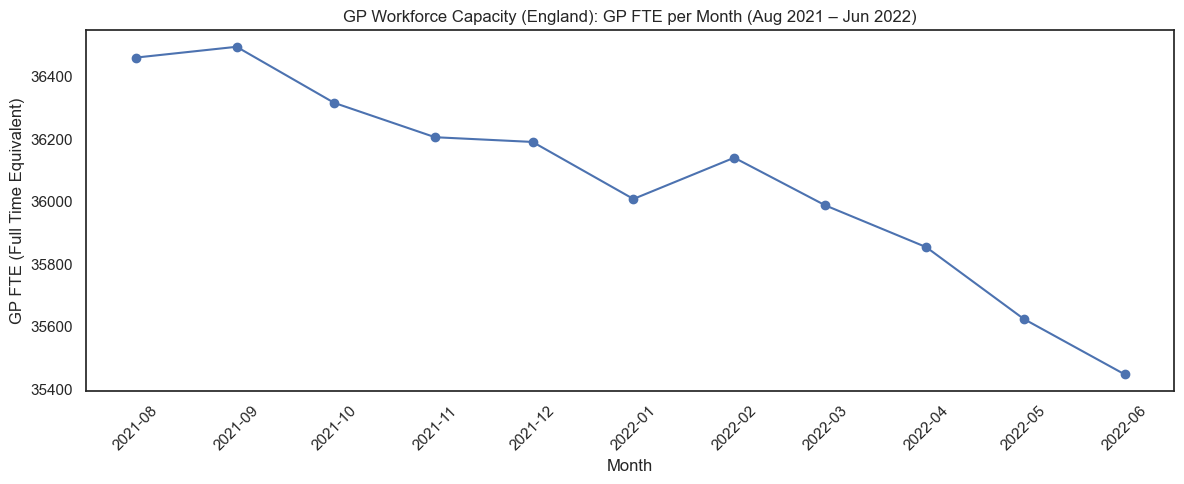

Percentage decrease in GP FTE (Aug 2021 → Jun 2022): 2.78%


,metric,month,fte
0,"All GPs 10,11,13",2021-08-01,"36,461"
1,"All GPs 10,11,13",2021-09-01,"36,495"
2,"All GPs 10,11,13",2021-10-01,"36,316"
3,"All GPs 10,11,13",2021-11-01,"36,206"
4,"All GPs 10,11,13",2021-12-01,"36,191"
5,"All GPs 10,11,13",2022-01-01,"36,009"
6,"All GPs 10,11,13",2022-02-01,"36,141"
7,"All GPs 10,11,13",2022-03-01,"35,988"
8,"All GPs 10,11,13",2022-04-01,"35,855"
9,"All GPs 10,11,13",2022-05-01,"35,626"


In [199]:
# Ensure month is datetime
gp_fte_aug21_jun22["month"] = pd.to_datetime(gp_fte_aug21_jun22["month"])

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gp_fte_aug21_jun22["month"], gp_fte_aug21_jun22["fte"], marker="o")

ax.set_title("GP Workforce Capacity (England): GP FTE per Month (Aug 2021 – Jun 2022)")
ax.set_xlabel("Month")
ax.set_ylabel("GP FTE (Full Time Equivalent)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Percentage decrease in GP FTE (Aug 2021 → Jun 2022): {((fte_appointments_merge['fte'].iloc[0] - fte_appointments_merge['fte'].iloc[-1]) / fte_appointments_merge['fte'].iloc[0]) * 100:.2f}%")

# Quick table view
gp_fte_aug21_jun22


In [200]:
# Merge GP FTE with monthly appointments cleanly on month

# 1) Work on copies
appts_merge = ar_monthly.copy()
fte_merge = gp_fte_aug21_jun22.copy()

# 2) Standardise both to a single 'month' column (month start)
appts_merge["month"] = (
    pd.to_datetime(appts_merge["appointment_month"], errors="coerce")
      .dt.to_period("M")
      .dt.to_timestamp()
)

fte_merge["month"] = (
    pd.to_datetime(fte_merge["month"], errors="coerce")
      .dt.to_period("M")
      .dt.to_timestamp()
)

# 3) Keep only relevant columns
appts_merge = appts_merge[["month", "total_appointments", "daily_average"]]
fte_merge = fte_merge[["month", "fte"]]

# 4) Merge cleanly
fte_appointments_merge = appts_merge.merge(
    fte_merge,
    on="month",
    how="inner"
).sort_values("month").reset_index(drop=True)

fte_appointments_merge


,month,total_appointments,daily_average,fte
0,2021-08-01,23852171,"795,072","36,461"
1,2021-09-01,28522501,"950,750","36,495"
2,2021-10-01,30303834,"1,010,128","36,316"
3,2021-11-01,30405070,"1,013,502","36,206"
4,2021-12-01,25140776,"838,026","36,191"
5,2022-01-01,25635474,"854,516","36,009"
6,2022-02-01,25355260,"845,175","36,141"
7,2022-03-01,29595038,"986,501","35,988"
8,2022-04-01,23913060,"797,102","35,855"
9,2022-05-01,27495508,"916,517","35,626"


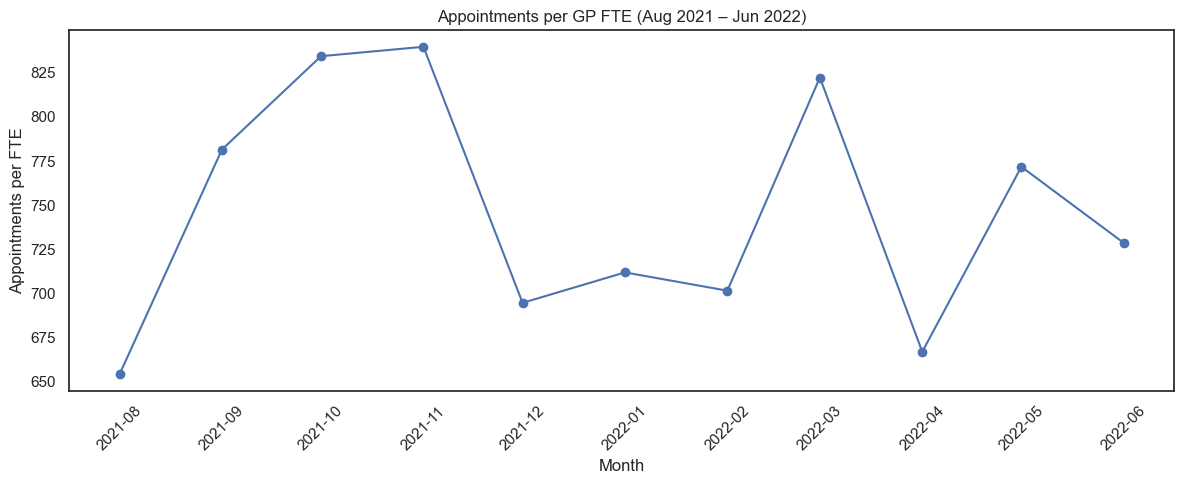

In [201]:
# comparison of appointments per month and GP FTE
# introduce a new metric, workloaf per GP
# compute the ratio of appointments per GP FTE

fte_appointments_merge["appointments_per_fte"] = (
    fte_appointments_merge["total_appointments"] /
    fte_appointments_merge["fte"]
)

plt.figure(figsize=(12,5))
plt.plot(
    fte_appointments_merge["month"],
    fte_appointments_merge["appointments_per_fte"],
    marker="o"
)
plt.title("Appointments per GP FTE (Aug 2021 – Jun 2022)")
plt.xlabel("Month")
plt.ylabel("Appointments per FTE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Raw appointment totals (millions) and GP FTE (~36,000) are on very different scales,
# so plotting them directly would not provide meaningful comparison.

# To make demand and capacity comparable, we calculate:
#     appointments_per_fte = total_appointments / FTE

# This represents the average number of appointments handled per GP FTE
# in each month and acts as a workload intensity indicator.

# If this metric trends upward, it suggests rising pressure per GP.
# If it fluctuates seasonally, it suggests temporary peaks rather than
# sustained structural deterioration.

# The line plot below therefore visualises workload per GP
# rather than raw appointment volume.


In [202]:
# Summary of Findings and Implications

# From Aug 2021 to Jun 2022, GP FTE declined modestly while total
# appointment volumes fluctuated across months.

# When normalising demand by capacity (appointments per FTE),
# workload per GP shows seasonal peaks rather than a continuous
# upward trend.

# This suggests that short-term pressure is cyclical rather than
# structurally accelerating within this timeframe.

# Therefore, the data supports targeted capacity planning during
# peak demand months rather than immediate blanket workforce expansion.

# However, the gradual decline in FTE highlights the importance of
# workforce retention to prevent longer-term structural strain.


### Statistical validation of demand–capacity relationship

R² = 0.030


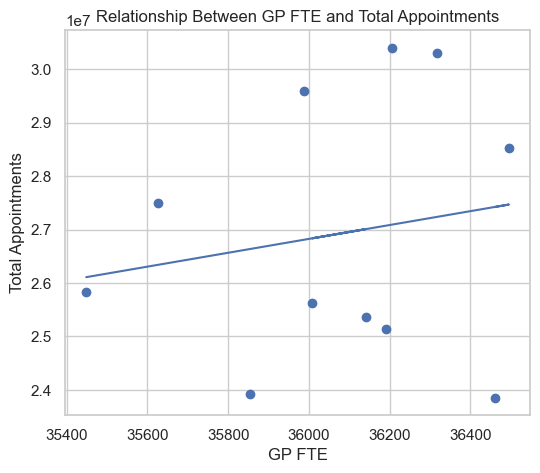

In [225]:
# R²: Relationship between FTE and Appointments

# Prepare data
X = fte_appointments_merge["fte"].astype(str).str.replace(",", "").astype(float).values.reshape(-1,1)
y = fte_appointments_merge["total_appointments"].astype(float).values

# Fit simple linear regression
model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)

print(f"R² = {r2:.3f}")

# Plot
plt.figure(figsize=(6,5))
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("GP FTE")
plt.ylabel("Total Appointments")
plt.title("Relationship Between GP FTE and Total Appointments")
plt.show()

# Only 3 percent of the variation in total appointments is explained by changes in GP FTE
# There is a very weak linear relationship between GP workforce size and total appointment volume.

# Workforce size is not the primary driver of appointment volume
 # Even though GP FTE is declining, appointment volumes fluctuate largely independently

# Demand dynamics dominate
 # Seasonality, patient behaviour, booking patterns

# The regression analysis shows that GP FTE explains only 3 percent of appointment volume variation, 
  # indicating that demand patterns and operational factors play a larger role 
     # than workforce size alone


Mean: 746.16
Standard Deviation: 67.18

Months flagged as unusual (|z| >= 2):
Empty DataFrame
Columns: [month, appointments_per_fte, z_score]
Index: []


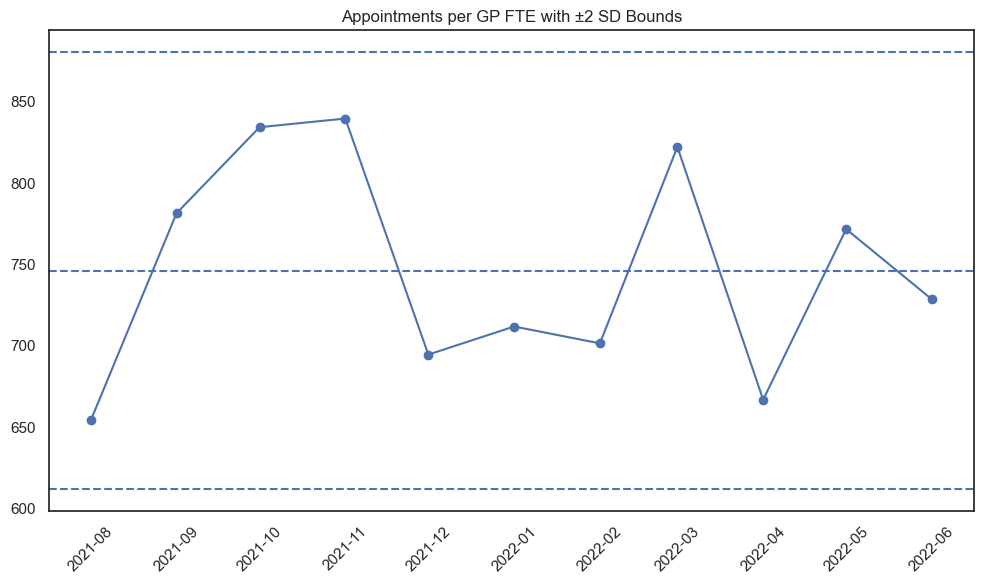

No months flagged as unusual (|z| >= 2).


In [205]:
# Z-score 
# identify whether any month is significantly above or below the average workload. 
# The z score measures how many standard deviations a value is from the mean.

mean_val = fte_appointments_merge["appointments_per_fte"].mean()
std_val = fte_appointments_merge["appointments_per_fte"].std()

fte_appointments_merge["z_score"] = (
    fte_appointments_merge["appointments_per_fte"] - mean_val
) / std_val

# Flag unusual months (|z| >= 2)
fte_appointments_merge["outlier_flag"] = (
    fte_appointments_merge["z_score"].abs() >= 2
)

print("Mean:", round(mean_val, 2))
print("Standard Deviation:", round(std_val, 2))
print("\nMonths flagged as unusual (|z| >= 2):")
print(fte_appointments_merge.loc[fte_appointments_merge["outlier_flag"], 
                                  ["month", "appointments_per_fte", "z_score"]])

plt.figure(figsize=(10, 6))

plt.plot(
    fte_appointments_merge["month"],
    fte_appointments_merge["appointments_per_fte"],
    marker="o"
)

plt.axhline(mean_val, linestyle="--")
plt.axhline(mean_val + 2*std_val, linestyle="--")
plt.axhline(mean_val - 2*std_val, linestyle="--")

plt.title("Appointments per GP FTE with ±2 SD Bounds")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

unusual = fte_appointments_merge.loc[
    fte_appointments_merge["z_score"].abs() >= 2,
    ["month", "appointments_per_fte", "z_score"]
]

if unusual.empty:
    print("No months flagged as unusual (|z| >= 2).")
else:
    print(unusual.to_string(index=False

# Interpretation
  #	No statistical outliers
      # No month falls outside ±2 standard deviations.
# This means no month had an unusually extreme workload per GP relative to the period average.

# Appointments per GP FTE remained statistically stable across the period despite:
  # Seasonal demand spikes
  # Falling GP FTE
  # DNA variation
                            
# The system is under pressure but not showing extreme workload spikes per GP.
                            

### Summary of findings

Overall activity and utilisation

• Total appointments fluctuate seasonally, peaking around Oct to Nov 2021 and Mar 2022
• Clear dip in Dec 2021 and especially Apr 2022
• Average daily utilisation mirrors this pattern
• No statistical outliers in appointments per GP FTE at ±2 standard deviations
• Workload per GP remains within expected variation despite volume swings

GP workforce capacity

• GP FTE declines from 36,461 in Aug 2021 to 35,449 in Jun 2022
• Overall decrease of 2.78 percent
• Workforce reduction is gradual but consistent
• R² between GP FTE and total appointments is only 0.03
→ Very weak relationship
→ Activity changes are not explained by GP headcount alone

Appointments per GP FTE

• High in Oct and Nov 2021
• Drops sharply in Dec 2021
• Recovers in Mar 2022
• Falls again in Apr 2022
• Despite falling FTE, workload per GP does not show extreme instability

Missed appointments DNA

• Average monthly DNA rate: 4.48 percent
• Range: 3.98 percent to 5.17 percent
• Highest DNA in Oct 2021
• Lowest DNA in Aug 2021
• Total DNA appointments across period: 13.3 million

Interpretation
DNA levels are relatively stable with moderate seasonal variation. There is no explosive spike, but even 4 to 5 percent at this scale represents significant lost capacity.

Lost utilisation impact

Given millions of appointments per month, even a 4 to 5 percent DNA rate translates into substantial lost consultation time. Combined with falling GP FTE, this compounds capacity pressure.

Booking behaviour

• Around 52 to 56 percent of appointments occur within 1 day of booking
• Peak short lead time in Jan 2022
• Lowest in Oct 2021
This suggests high demand for rapid access and potential strain on short term scheduling.

Appointment modes

• Face to face remains dominant
• Telephone consistently second largest
• Video and home visits remain comparatively small
• No dramatic structural shift in mode mix during this period

Healthcare professional type

• GPs deliver majority of appointments
• Other practice staff contribute a large and stable share
• This indicates partial workload distribution away from GPs
• However, declining GP FTE suggests rising pressure per clinician over time

Service setting

• Unmapped and PCN volumes are substantial
• Extended Access Provision is much smaller
• Monthly variation exists but no structural collapse in any category

Overall conclusion
	1.	Activity is seasonal, not structurally collapsing
	2.	DNA rate is stable but materially impacts utilisation
	4.	Appointment volume is weakly correlated with GP FTE
	5.	Demand for rapid access remains high
	6.	Capacity pressure is more likely driven by demand dynamics and workforce mix than by extreme utilisation anomalies



Final recommendations:
	•	Reduce DNA appointments as the primary efficiency lever. Even a one percentage point reduction would release millions of appointment slots without expanding workforce capacity. The current average DNA rate is 4.48 percent, equating to approximately 13 million missed appointments over the period analysed.
	•	Use seasonal workforce planning to manage predictable demand spikes. Introduce additional staff or locum cover ahead of peak months rather than reacting once pressure materialises.
	•	Protect face to face capacity. Demand data shows it remains the dominant mode and should not be significantly reduced.
	•	Deploy remote consultations strategically for low complexity cases to optimise clinician time while maintaining access.
	•	Monitor patient outcomes across consultation modes to ensure efficiency improvements do not compromise quality of care.

